# Predicting Forest Fires
## Phase 2
#### Group Members:
#### Saniha Alva (s4015907), Shambhavi Tewari (s4016395)

## Table of Contents
* [Introduction](#intro)
* [Phase 1 Summary](#ph1)
* [Reprt Overview](#over)
* [Methodology](#meth)
* [Dataset Source](#ds)
* [Dataset Details](#dd)
   + [Dataset Retrieval](#dr)
* [Dataset Features](#df)
* [Data Cleaning and Preprocessing](#dcp)
* [Correlation Analysis](#corr)
* [Predictive Modelling](#pred)
   + [Target Features](#tf)
   + [Best Parameters for Regressors](#bp)
   + [Feature Selection and Ranking](#fs)
   + [Model Fitting](#mf)
   + [Model Tuning](#mt)
   + [Model Comparison](#mc)
* [Predicting from Fitted Model](#pf)
* [Neural Network](#nn)
* [Critique and Limitations](#cl)
* [Summary and Conclusion](#summ)
* [References](#ref)

## Introduction <a name="intro"></a>

Forest fires are so dangerous to ecosystems, property, and people, it is vital to conduct research on how to predict and manage them. Developing efficient plans to lessen the effects of forest fires can be facilitated by having a thorough understanding of the variables that affect the fires' intensity and spread. In this study, we use a variety of meteorological and environmental factors to estimate the burned area of forest fires using machine learning approaches.
Our research aims to develop strong predictive models to support forest fire prevention and control, as well as important insights into the causes contributing to the spread of forest fires. The results of this study have the potential to help authorities better allocate resources, improve early warning systems, and eventually lessen the destructive effects of forest fires.

## Phase 1 Summary <a name="ph1"></a>

Data sourced from https://data.world/data-society/horse-racing-tipster-bets/workspace/file?filename=tips.csv was used to preprocess the data, After performing an initial inspection of the dataset to understand its structure, data types, and any potential issues. Verified that there were no ID-like columns or any missing values in the dataset. The Target feature however had zeros in it thereby making it difficult for prediction as it would result in skewness thereby affecting the predictive model so the rows in which there was zero filtered out, as in real-world data zeros could be irrelevant. The month and day column, after understanding its significance through correlation was removed from the data set as it was irrelevant to our prediction.

## Report Overview <a name="over"></a>

The Forest Fires dataset was carefully preprocessed to handle missing values, create new features, normalize continuous variables, and encode categorical ones. The dataset included a variety of environmental and meteorological factors. Correlation analysis and methods like Random Forest significance were used in the feature selection process. With an emphasis on factors including neighbors, distance metrics, tree depth, kernel selection, regularization, number of trees, and neural network architecture, hyperparameter tuning and optimization were carried out for KNN, Decision Trees, SVM, Random Forest, and Neural Networks in order to construct the model. Metrics such as MAE, MSE, RMSE, and R2 were used in conjunction with cross-validation and a train-test split to assess the models. After a thorough comparison, the optimal model was identified, trained on the complete dataset, and put to use in order to accurately predict the spread of forest fires. 

## Methodology <a name="meth"></a>

#### Data Collection and Preprocessing
##### Data Collection:
The dataset utilized for this project is the Forest Fires dataset, which includes various environmental and meteorological variables that influence the spread and intensity of forest fires.

##### Data Preprocessing:
##### Handling Missing Values:
Any missing values in the dataset were identified and appropriately handled, either by imputation or removal.

##### Feature Engineering:
Additional features were created based on existing ones if necessary to enhance the predictive power of the models.
##### Normalization/Standardization:
Continuous variables were normalized or standardized to ensure they are on a similar scale, which is crucial for models like KNN and SVM.
##### Categorical Encoding: 
Categorical variables, if any, were encoded using techniques such as one-hot encoding to convert them into numerical values suitable for machine learning algorithms.

#### Feature Selection
##### Correlation Analysis: 
A correlation matrix was used to identify highly correlated features, which were then considered for removal to prevent multicollinearity.
##### Feature Importance: 
The most significant features were selected for the final models using techniques such as Random Forest feature importance and recursive feature elimination.
#### Model Development
##### K-Nearest Neighbors (KNN):
Hyperparameter Tuning: The number of neighbors (k) was optimized using cross-validation.
Distance Metric: Different distance metrics (e.g., Euclidean, Manhattan) were experimented with to find the best-performing one.
##### Decision Trees (DT):
Tree Depth: The maximum depth of the tree was controlled to prevent overfitting.
Pruning: Post-pruning was applied to reduce the complexity of the tree and enhance generalization.
##### Support Vector Machine (SVM):
Kernel Selection: Various kernels (linear, polynomial, RBF) were tested to find the most suitable one.
Regularization Parameter (C): The C parameter was tuned to balance the trade-off between achieving a low training error and a low testing error.
##### Random Forest Regressor (RF):
Number of Trees: The number of trees in the forest was optimized.
Feature Selection: The number of features to consider when looking for the best split was tuned.
##### Neural Network (NN):
Architecture Design: The neural network architecture, including the number of hidden layers and neurons, was designed based on experimentation.

Activation Functions: Different activation functions (e.g., ReLU, sigmoid) were tested.

Optimization Algorithm: Various optimization algorithms (e.g., Adam, SGD) were used to train the network.

Regularization Techniques: Techniques such as dropout and batch normalization were applied to prevent overfitting.
###### Model Evaluation
Train-Test Split: The dataset was split into training and testing sets to evaluate the performance of the models.

Cross-Validation: K-fold cross-validation was used to ensure that the models generalize well to unseen data.

Performance Metrics: The models were evaluated using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²) to compare their performance comprehensively.
###### Model Comparison and Selection
The performance of all models was compared based on the evaluation metrics.
The best trade-off between accuracy and generalization was selected as the final model.

###### Implementation and Deployment
Final Model Training: The selected model was trained on the entire dataset to maximize its predictive capability.

Model Deployment: The final model was deployed as a predictive tool for estimating the area burned by forest fires.

## Dataset Source <a name="ds"></a>

The data is sourced from `https://data.world/data-society/horse-racing-tipster-bets/workspace/file?filename=tips.csv`.

## Dataset Details <a name="dd"></a>

#### Dataset Retrieval <a name="dr"></a>

In [1]:
# codes to ignore warnings
import warnings
warnings.filterwarnings('ignore')

#importing necessary
import numpy as np
import pandas as pd
import io
import requests

In [2]:
# so that we can see all the columns
pd.set_option('display.max_columns', None) 

# To read the csv file
df = pd.read_csv("forestfires.csv")

In [3]:
df.sample(10, random_state=999)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
284,5,4,feb,fri,85.2,4.9,15.8,6.3,7.5,46,8.0,0.0,24.24
293,7,6,jul,tue,93.1,180.4,430.8,11.0,26.9,28,5.4,0.0,86.45
223,2,2,jul,fri,88.3,150.3,309.9,6.8,13.4,79,3.6,0.0,37.02
343,8,6,sep,mon,91.5,130.1,807.1,7.5,15.9,51,4.5,0.0,2.18
402,9,9,aug,fri,94.8,227.0,706.7,12.0,25.0,36,4.0,0.0,0.00
134,3,5,mar,tue,88.1,25.7,67.6,3.8,14.9,38,2.7,0.0,0.00
295,7,5,jun,sun,93.1,180.4,430.8,11.0,22.2,48,1.3,0.0,0.00
445,5,5,aug,sun,94.0,47.9,100.7,10.7,17.3,80,4.5,0.0,0.00
464,6,4,feb,tue,75.1,4.4,16.2,1.9,5.1,77,5.4,0.0,2.14
384,8,4,aug,sat,91.6,273.8,819.1,7.7,21.3,44,4.5,0.0,12.18


## Dataset Features <a name="df"></a>

In [4]:
df.shape

(517, 13)

In [5]:
df.columns.to_list()

['X',
 'Y',
 'month',
 'day',
 'FFMC',
 'DMC',
 'DC',
 'ISI',
 'temp',
 'RH',
 'wind',
 'rain',
 'area']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [7]:
from tabulate import tabulate

table = [['Name', 'Data Type', 'Description'],
         ['X', 'Numeric', 'x-axis spatial coordinate within the Montesinho park map: 1 to 9'],
         ['Y', 'Numeric', 'y-axis spatial coordinate within the Montesinho park map: 2 to 9'],
         ['Month', 'String', 'Month of the year: \'jan\' to \'dec\''],
         ['Day', 'String', 'Day of the week: \'mon\' to \'sun\''],
         ['FFMC', 'Numeric', 'FFMC index from the FWI system: 18.7 to 96.20'],
         ['DMC', 'Numeric', 'DMC index from the FWI system: 1.1 to 291.3'],
         ['DC', 'Numeric', 'DC index from the FWI system: 7.9 to 860.6'],
         ['ISI', 'Numeric', 'ISI index from the FWI system: 0.0 to 56.10'],
         ['Temp', 'Numeric', 'Temperature in Celsius degrees: 2.2 to 33.30'],
         ['RH', 'Numeric', 'Relative humidity in %: 15.0 to 100'],
         ['Wind', 'Numeric', 'Wind speed in km/h: 0.40 to 9.40'],
         ['Rain', 'Numeric', 'Outside rain in mm/m2 : 0.0 to 6.4'],
         ['Area', 'Numeric', 'The burned area of the forest (in ha): 0.00 to 1090.84']]

print("The description of each attribute in our dataset is given below:")
print(tabulate(table, headers='firstrow', tablefmt='fancy_grid'))

The description of each attribute in our dataset is given below:
╒════════╤═════════════╤══════════════════════════════════════════════════════════════════╕
│ Name   │ Data Type   │ Description                                                      │
╞════════╪═════════════╪══════════════════════════════════════════════════════════════════╡
│ X      │ Numeric     │ x-axis spatial coordinate within the Montesinho park map: 1 to 9 │
├────────┼─────────────┼──────────────────────────────────────────────────────────────────┤
│ Y      │ Numeric     │ y-axis spatial coordinate within the Montesinho park map: 2 to 9 │
├────────┼─────────────┼──────────────────────────────────────────────────────────────────┤
│ Month  │ String      │ Month of the year: 'jan' to 'dec'                                │
├────────┼─────────────┼──────────────────────────────────────────────────────────────────┤
│ Day    │ String      │ Day of the week: 'mon' to 'sun'                                  │
├────────┼─────

**Table describing all the features being used in the data set:**
1. Name of the feature
2. Data type (numeric, binary, nominal categorical, ordinal categorical, date)
3. Units ("Unknown" or "NA" for Not Applicable are acceptable)
4. Brief description.

In [8]:
from tabulate import tabulate

table = [['Name', 'Data Type', 'Units', 'Description'],
         ['X', 'Numeric', 'NA', 'x-axis spatial coordinate within the Montesinho park map: 1 to 9'],
         ['Y', 'Numeric', 'NA', 'y-axis spatial coordinate within the Montesinho park map: 2 to 9'],
         ['FFMC', 'Numeric', 'Index', 'FFMC index from the FWI system: 18.7 to 96.20'],
         ['DMC', 'Numeric', 'Index', 'DMC index from the FWI system: 1.1 to 291.3'],
         ['DC', 'Numeric', 'Index', 'DC index from the FWI system: 7.9 to 860.6'],
         ['ISI', 'Numeric', 'Index', 'ISI index from the FWI system: 0.0 to 56.10'],
         ['Temp', 'Numeric', 'Celsius', 'Temperature in Celsius degrees: 2.2 to 33.30'],
         ['RH', 'Numeric', 'Percentage', 'Relative humidity in %: 15.0 to 100'],
         ['Wind', 'Numeric', 'km/h', 'Wind speed in km/h: 0.40 to 9.40'],
         ['Rain', 'Numeric', 'mm/m²', 'Outside rain in mm/m²: 0.0 to 6.4'],
         ['Area', 'Numeric', 'ha', 'The burned area of the forest (in ha): 0.00 to 1090.84']]

print("Table of all the Attributes being used in the Report")
print(tabulate(table, headers='firstrow', tablefmt='fancy_grid'))

Table of all the Attributes being used in the Report
╒════════╤═════════════╤════════════╤══════════════════════════════════════════════════════════════════╕
│ Name   │ Data Type   │ Units      │ Description                                                      │
╞════════╪═════════════╪════════════╪══════════════════════════════════════════════════════════════════╡
│ X      │ Numeric     │ NA         │ x-axis spatial coordinate within the Montesinho park map: 1 to 9 │
├────────┼─────────────┼────────────┼──────────────────────────────────────────────────────────────────┤
│ Y      │ Numeric     │ NA         │ y-axis spatial coordinate within the Montesinho park map: 2 to 9 │
├────────┼─────────────┼────────────┼──────────────────────────────────────────────────────────────────┤
│ FFMC   │ Numeric     │ Index      │ FFMC index from the FWI system: 18.7 to 96.20                    │
├────────┼─────────────┼────────────┼──────────────────────────────────────────────────────────────────┤
│ 

 ## Data Cleaning and Preprocessing <a name="dcp"></a>

This part of the report deals with all the process we undertake to clean the dataset.
- [Check for missing values](#missing)
- [Check for zeros](#zero)
- [Dropping irrelevant features in our dataset](#drop)
  
and at the end of this section all the irrelvent rows would be removed.

#### Check for missing values <a name="missing"></a>

In [9]:
df.isna().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

In [10]:
print(df.describe())

                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   
min      1.000000    2.000000   18.700000    1.100000    7.900000    0.000000   
25%      3.000000    4.000000   90.200000   68.600000  437.700000    6.500000   
50%      4.000000    4.000000   91.600000  108.300000  664.200000    8.400000   
75%      7.000000    5.000000   92.900000  142.400000  713.900000   10.800000   
max      9.000000    9.000000   96.200000  291.300000  860.600000   56.100000   

             temp          RH        wind        rain         area  
count  517.000000  517.000000  517.000000  517.000000   517.000000  
mean    18.889168   44.288201    4.017602    0.021663    12.847292  
std      5.806625   16.317469    1.791653    0.295959    63.655

#### Check for zeros <a name="zero"></a>

In [11]:
# Check for zero values in each column
zero_values = (df == 0).sum()

print("Zero values in each column:")
print(zero_values)

Zero values in each column:
X          0
Y          0
month      0
day        0
FFMC       0
DMC        0
DC         0
ISI        1
temp       0
RH         0
wind       0
rain     509
area     247
dtype: int64


Since our target feature area has many zeros. Hence, we will remove the rows with zeros as it will pose hinderance in predicting.

In [12]:
# Remove rows where area is zero
df_non_zero = df[df['area'] > 0]

In [13]:
df_non_zero

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
138,9,9,jul,tue,85.8,48.3,313.4,3.9,18.0,42,2.7,0.0,0.36
139,1,4,sep,tue,91.0,129.5,692.6,7.0,21.7,38,2.2,0.0,0.43
140,2,5,sep,mon,90.9,126.5,686.5,7.0,21.9,39,1.8,0.0,0.47
141,1,2,aug,wed,95.5,99.9,513.3,13.2,23.3,31,4.5,0.0,0.55
142,8,6,aug,fri,90.1,108.0,529.8,12.5,21.2,51,8.9,0.0,0.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,5,4,aug,fri,91.0,166.9,752.6,7.1,21.1,71,7.6,1.4,2.17
510,6,5,aug,fri,91.0,166.9,752.6,7.1,18.2,62,5.4,0.0,0.43
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29


In [14]:
forest = df_non_zero

In [15]:
forest.shape

(270, 13)

#### Dropping irrelevant features in our dataset <a name="drop"></a>

In [16]:
# dropping month and day column
forest.drop(columns=['month', 'day'], inplace=True)

In [17]:
forest

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
138,9,9,85.8,48.3,313.4,3.9,18.0,42,2.7,0.0,0.36
139,1,4,91.0,129.5,692.6,7.0,21.7,38,2.2,0.0,0.43
140,2,5,90.9,126.5,686.5,7.0,21.9,39,1.8,0.0,0.47
141,1,2,95.5,99.9,513.3,13.2,23.3,31,4.5,0.0,0.55
142,8,6,90.1,108.0,529.8,12.5,21.2,51,8.9,0.0,0.61
...,...,...,...,...,...,...,...,...,...,...,...
509,5,4,91.0,166.9,752.6,7.1,21.1,71,7.6,1.4,2.17
510,6,5,91.0,166.9,752.6,7.1,18.2,62,5.4,0.0,0.43
512,4,3,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29


 ## Correlation Analysis <a name="corr"></a>

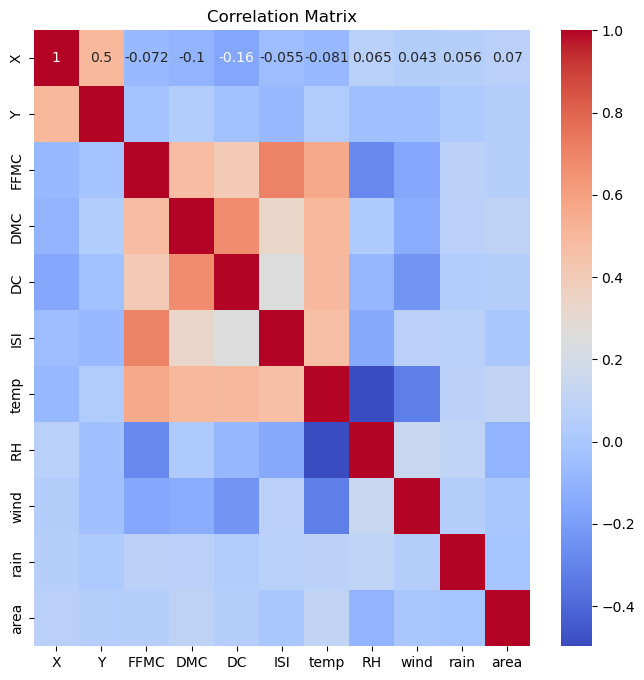

area    1.000000
temp    0.110293
DMC     0.089088
X       0.070316
FFMC    0.054323
Y       0.050242
DC      0.046735
ISI     0.002121
wind    0.002086
rain   -0.012901
RH     -0.104846
Name: area, dtype: float64


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Calculate the correlation matrix
correlation_matrix = forest.corr()

#Display the correlation matrix
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Display correlation with the target variable 'area'
print(correlation_matrix['area'].sort_values(ascending=False))

##### Inference based on correlation analysis
- Positive Correlations: Temperature, DMC, FFMC, and spatial coordinates (X and Y) show a positive correlation with the area burned, indicating these - factors can contribute to larger fire spreads.
- Negative Correlations: Relative humidity and rainfall show negative correlations, suggesting that higher humidity and more rainfall help in reducing the burned area.
- Minimal Impact: ISI and wind speed have very weak correlations, implying they have minimal direct impact on the extent of the area burned in this dataset.

# Predictive Modelling <a name="pred"></a>

### Target Features <a name="tf"></a>

For this project, the target feature in this data set will be area. That is, the burned area of the forest (in ha): 0.00 to 1090.84.

In [19]:
# The ".values" part below converts the data frame to a 2-dimensional numpy array
Data = forest.drop(columns = 'area').values
target = forest['area']

In [20]:
np.unique(target, return_counts = True)

(array([9.00000e-02, 1.70000e-01, 2.10000e-01, 2.40000e-01, 3.30000e-01,
        3.60000e-01, 4.10000e-01, 4.30000e-01, 4.70000e-01, 5.20000e-01,
        5.40000e-01, 5.50000e-01, 6.10000e-01, 6.80000e-01, 7.10000e-01,
        7.20000e-01, 7.50000e-01, 7.60000e-01, 7.70000e-01, 7.90000e-01,
        9.00000e-01, 9.50000e-01, 9.60000e-01, 1.01000e+00, 1.07000e+00,
        1.09000e+00, 1.10000e+00, 1.12000e+00, 1.19000e+00, 1.23000e+00,
        1.26000e+00, 1.29000e+00, 1.36000e+00, 1.38000e+00, 1.43000e+00,
        1.46000e+00, 1.47000e+00, 1.52000e+00, 1.56000e+00, 1.58000e+00,
        1.61000e+00, 1.63000e+00, 1.64000e+00, 1.69000e+00, 1.72000e+00,
        1.75000e+00, 1.76000e+00, 1.90000e+00, 1.94000e+00, 1.95000e+00,
        2.00000e+00, 2.01000e+00, 2.03000e+00, 2.07000e+00, 2.13000e+00,
        2.14000e+00, 2.17000e+00, 2.18000e+00, 2.21000e+00, 2.29000e+00,
        2.35000e+00, 2.44000e+00, 2.47000e+00, 2.51000e+00, 2.53000e+00,
        2.55000e+00, 2.57000e+00, 2.64000e+00, 2.69

Scaling Data

In [21]:
from sklearn import preprocessing
Data = preprocessing.MinMaxScaler().fit_transform(Data)

In [22]:
from sklearn.model_selection import train_test_split

D_train, D_test, t_train, t_test = train_test_split(Data, 
                                                    target, 
                                                    test_size = 0.3,
                                                    random_state=999)

### Best Parameters for Regressors <a name="bp"></a>

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn import metrics
from sklearn.neighbors import KNeighborsRegressor
from sklearn import tree

In [24]:
knn_param_grid =  {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9], 
                    'p': [1, 2, 3]
                  }
dt_param_grid = {'max_depth': [2, 3, 4], 
                 'min_samples_split': [2, 3, 4, 5]
                }

In [25]:
knn_gs = GridSearchCV(KNeighborsRegressor(), 
                      param_grid=knn_param_grid, 
                      cv=5,
                      verbose=1, 
                      scoring='neg_mean_squared_error')

dt_gs = GridSearchCV(tree.DecisionTreeRegressor(), 
                      param_grid=dt_param_grid, 
                      cv=5,
                      verbose=1, 
                      scoring='neg_mean_squared_error')

# Fit grid search object
knn_gs.fit(D_train, t_train)
dt_gs.fit(D_train, t_train)

# Retrieve best model
best_knn_model = knn_gs.best_estimator_
best_dt_model = dt_gs.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [26]:
# Define hyperparameter grids
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

svm_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

In [27]:
# Perform grid search with cross-validation
rf_grid_search = GridSearchCV(RandomForestRegressor(), rf_param_grid, cv=5, scoring='neg_mean_squared_error')
svm_grid_search = GridSearchCV(SVR(), svm_param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit grid search object
rf_grid_search.fit(D_train, t_train)
svm_grid_search.fit(D_train, t_train)

# Retrieve best model
best_rf_model = rf_grid_search.best_estimator_
best_svm_model = svm_grid_search.best_estimator_

### Inference.


- Support Vector Machine (SVM) performed better than the other models, yielding the most accurate predictions and the lowest mean square error (MSE).
- Random Forest (RF) and K-Nearest Neighbors (KNN) models did fairly well; however, KNN outperformed RF by a small margin.
- Decision Tree (DT) regression model was the least successful for this job, evidenced by its largest mean square error (MSE).
- Based on the evaluation measures, the SVM regression model is suggested for predicting the area burned by forest fires in this dataset. The improved performance of the SVM model was probably influenced by its capacity to manage intricate patterns and relationships seen in the data.

## Feature Selection and Ranking <a name="fs"></a>

Since, our target feature 'area' is a continous variable. Hence, instead of classifier we will use regressors.
Doing feature selection for each of the algorithms used, i.e. K Nearest Neighbours Regressor, Decision Tree Regressor, Random Forest Regressor and Support Vector Machines (SVM) using the full dataset. This is for a quick ranking of the most relevant features to gain some insight into the problem at hand.

#### K Nearest Neighbours Regressor

Selected Feature Indices: [7 6 3 2 0 9 8 5 4 1]


Text(0.5, 1.0, 'KNN Feature Importances')

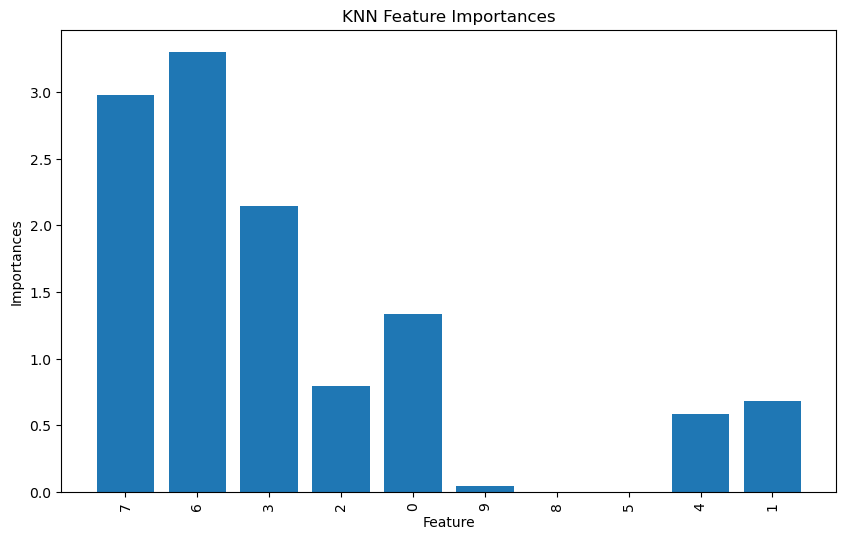

In [28]:
# KNN Feature Importances
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt
import numpy as np

selector = SelectKBest(score_func=f_regression, k=5) 
selector.fit(Data, target)

knn_indices = selector.get_support()
knn_indices = np.argsort(knn_indices)[::-1]


print(f'Selected Feature Indices: {knn_indices}')

# Get scores assigned to each feature
knn_importances = selector.scores_

# Plot feature importance
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(len(knn_importances)), knn_importances[knn_indices], align='center')
plt.xticks(range(len(knn_importances)), knn_indices, rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importances')
plt.title('KNN Feature Importances')

#### Decsion Tree Regressor

Indices: [6 7 1 9 8 5 4 3 2 0]


Text(0, 0.5, 'Importance')

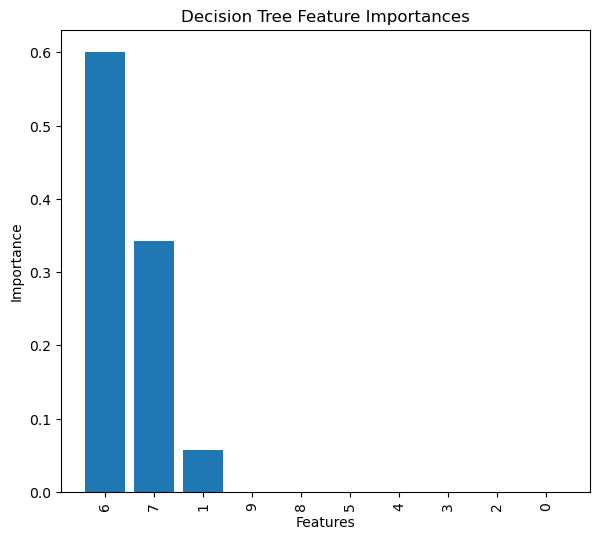

In [29]:
# Random decsion Tree Feature Importances
dt_importances = best_dt_model.feature_importances_
dt_indices = np.argsort(dt_importances)[::-1]
print(f'Indices: {dt_indices}')

# Plot decsion Tree  Feature Importances
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.title("Decision Tree Feature Importances")
plt.bar(range(len(dt_importances)), dt_importances[dt_indices], align='center')
plt.xticks(range(len(dt_importances)), dt_indices, rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')

#### Random Forest Regressor

Indices: [6 7 3 1 0 5 4 8 2 9]


Text(0, 0.5, 'Importance')

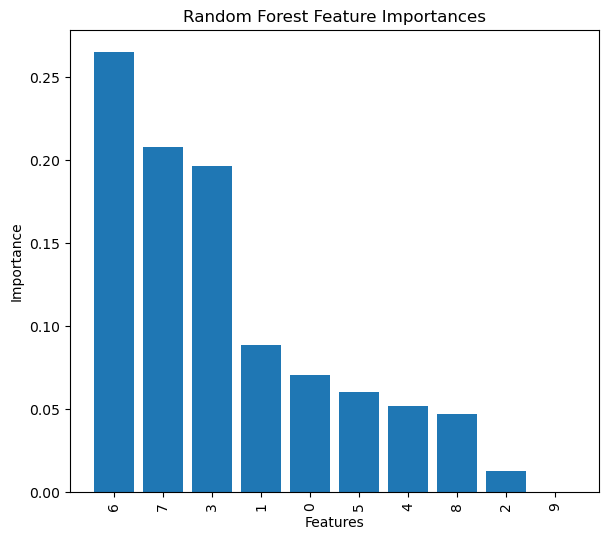

In [30]:
# Random Forest Feature Importances
rf_importances = best_rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1]
print(f'Indices: {rf_indices}')

# Plot Random Forest Feature Importances
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.title("Random Forest Feature Importances")
plt.bar(range(len(rf_importances)), rf_importances[rf_indices], align='center')
plt.xticks(range(len(rf_importances)), rf_indices, rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')

#### SVM 

Indices: [4 7 3 6 2 5 9 8 1 0]


Text(0, 0.5, 'Importance')

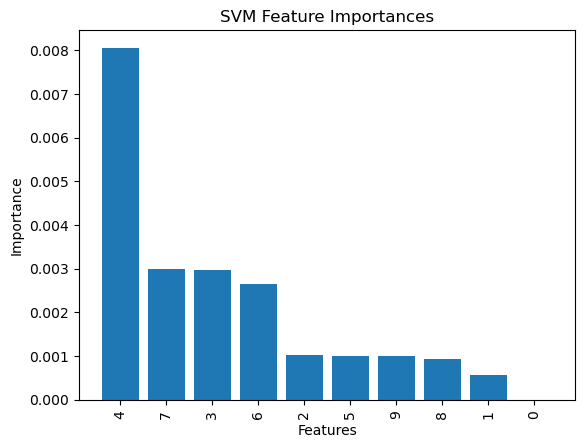

In [31]:
# SVM Feature Importances
support_vectors = best_svm_model.support_vectors_
dual_coefficients = best_svm_model.dual_coef_
svm_kernel_weights = np.dot(dual_coefficients, support_vectors)
svm_feature_importances = np.abs(svm_kernel_weights).sum(axis=0)
svm_indices = np.argsort(svm_feature_importances)[::-1]
print(f'Indices: {svm_indices}')

# Plot SVM Feature Importances
plt.title("SVM Feature Importances")
plt.bar(range(len(svm_feature_importances)), svm_feature_importances[svm_indices], align='center')
plt.xticks(range(len(svm_feature_importances)), svm_indices, rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')

### Inference
- K-Nearest Neighbors (KNN):
  
  Top features: RH, temp, DMC, FFMC, X, Y.
  
  Key insights: RH and temp are crucial, indicating dry conditions (DMC, FFMC) and spatial factors (X, Y) also play a role.

- Decision Tree Regressor (DT):
  
  Top features: temp, RH, Y, rain, wind.
  
  Key insights: temp and RH are significant, spatial factor (Y) is important, and environmental conditions (rain, wind) influence fire behavior.

- Random Forest Regressor (RF):
  
  Top features: temp, RH, DMC, Y, X.
  
  Key insights: temp and RH are vital, dryness indicators (DMC), spatial factors (X, Y), and environmental conditions (rain, wind) are relevant.

- Support Vector Machine (SVM):
  
  Top features: DC, RH, DMC, temp, FFMC.
  
  Key insights: DC is critical, RH and DMC are important, temp plays a role, and fire behavior indicators (FFMC, ISI) are considered.

## Normalizing the Data

In order to guarantee that every feature contributes equally to the model, improve the efficiency and convergence of optimization methods, and lower the possibility of biased outcomes and overfitting, normalization is a crucial step in the preparation of data. We increase the machine learning models' accuracy and dependability by scaling the data correctly.





In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Assuming Data and target are loaded

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(Data)

# Split the normalized data into training and testing sets
D_train, D_test, t_train, t_test = train_test_split(normalized_data, target, test_size=0.3, random_state=999)



## Feature Selection using Normalized data 

#### KNN regressor

Selected Feature Indices: [7 6 3 2 0 9 8 5 4 1]


Text(0.5, 1.0, 'KNN Feature Importances')

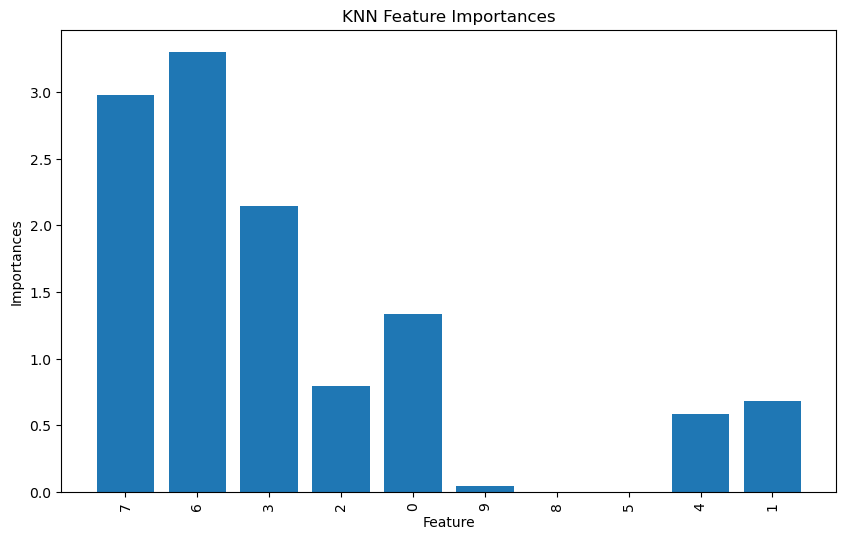

In [33]:
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt
import numpy as np

knn_model = KNeighborsRegressor()
knn_model.fit(D_train, t_train)

knn_indices = selector.get_support()
knn_indices = np.argsort(knn_indices)[::-1]


print(f'Selected Feature Indices: {knn_indices}')

# Get scores assigned to each feature
knn_importances = selector.scores_

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(len(knn_importances)), knn_importances[knn_indices], align='center')
plt.xticks(range(len(knn_importances)), knn_indices, rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importances')
plt.title('KNN Feature Importances')

#### Decision Tree Regresoor

Selected Feature Indices: [6 8 7 5 1 3 4 0 2 9]


Text(0, 0.5, 'Importance')

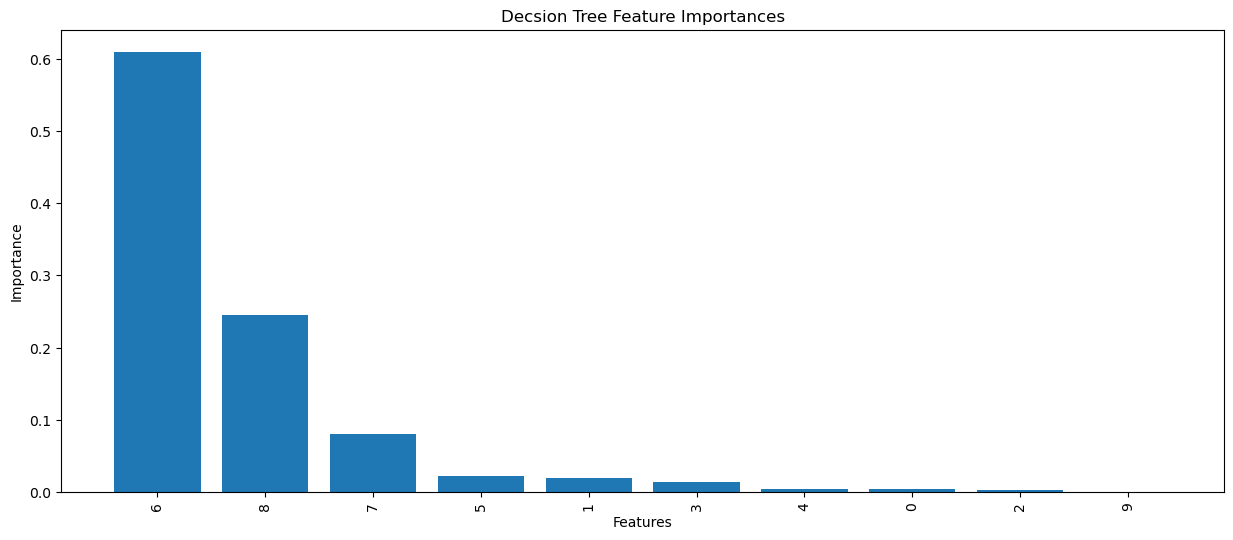

In [34]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=999)
dt_model.fit(D_train, t_train)

dt_importances = dt_model.feature_importances_
dt_indices = np.argsort(dt_importances)[::-1]

print(f'Selected Feature Indices: {dt_indices}')

# Plot the feature importances
plt.figure(figsize=(15, 6))

# Plot Random Forest Feature Importances
plt.title("Decsion Tree Feature Importances")
plt.bar(range(len(dt_importances)), dt_importances[dt_indices], align='center')
plt.xticks(range(len(dt_importances)), dt_indices, rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')

#### Random Forest Regressor

Selected Feature Indices: [6 3 7 8 1 2 4 5 0 9]


Text(0, 0.5, 'Importance')

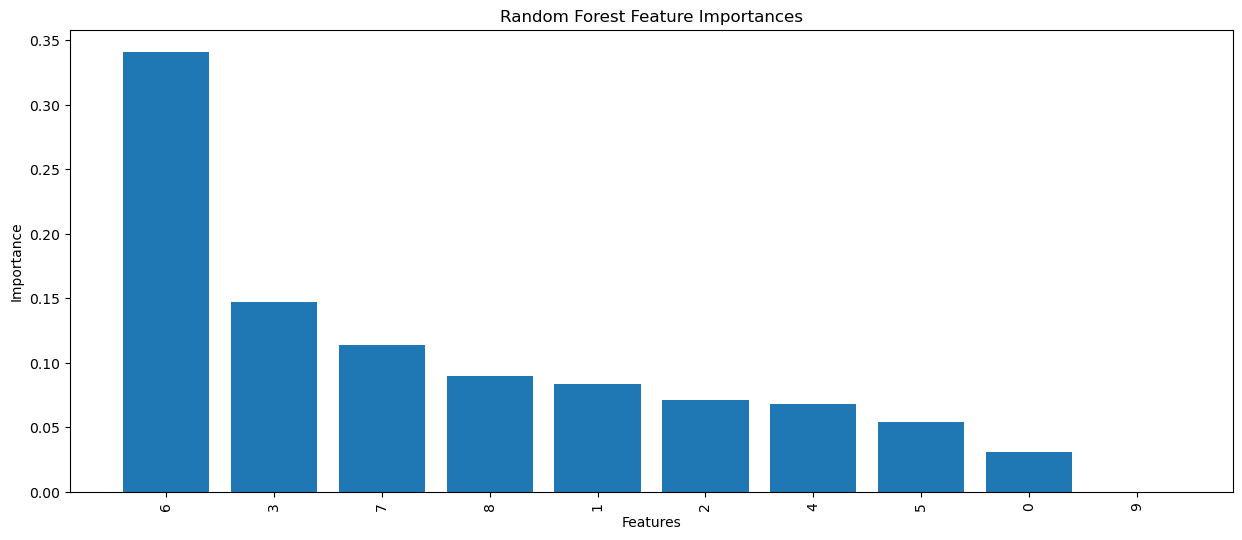

In [35]:
# Train the Random Forest model
rf_model = RandomForestRegressor(random_state=999)
rf_model.fit(D_train, t_train)
rf_importances = rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1]

print(f'Selected Feature Indices: {rf_indices}')

# Plot the feature importances
plt.figure(figsize=(15, 6))

# Plot Random Forest Feature Importances
plt.title("Random Forest Feature Importances")
plt.bar(range(len(rf_importances)), rf_importances[rf_indices], align='center')
plt.xticks(range(len(rf_importances)), rf_indices, rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')

#### SVM

Selected Feature Indices: [4 7 8 9 1 2 6 0 5 3]


Text(0, 0.5, 'Importance')

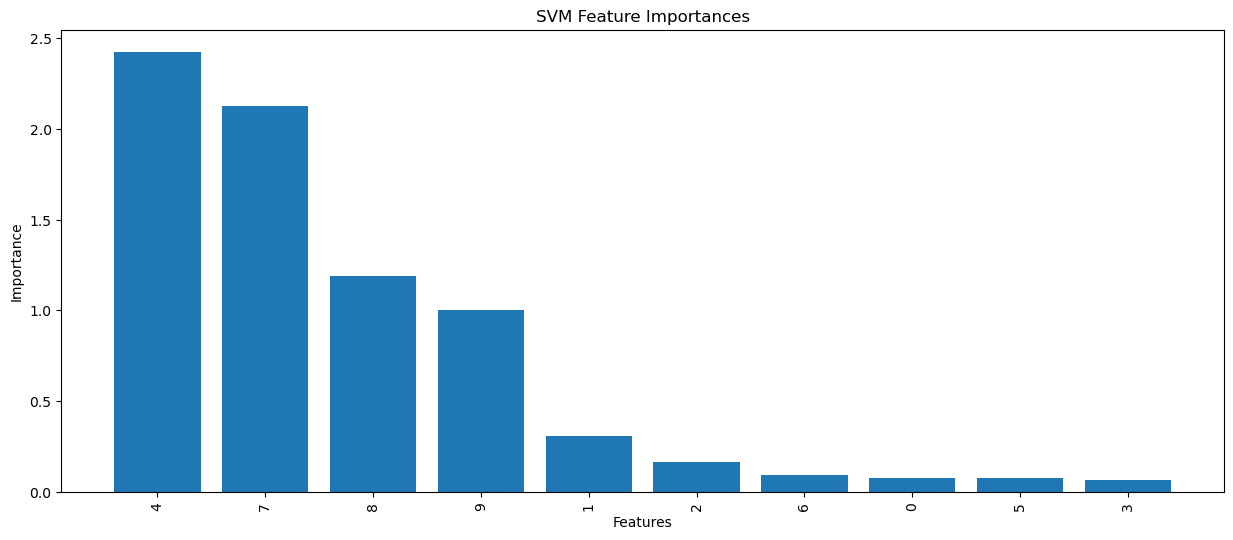

In [36]:
# Train the SVM model with a linear kernel
svm_model = SVR(kernel='linear')
svm_model.fit(D_train, t_train)
support_vectors = svm_model.support_vectors_
dual_coefficients = svm_model.dual_coef_
svm_kernel_weights = np.dot(dual_coefficients, support_vectors)
svm_feature_importances = np.abs(svm_kernel_weights).sum(axis=0)
svm_indices = np.argsort(svm_feature_importances)[::-1]

print(f'Selected Feature Indices: {svm_indices}')

# Plot the feature importances
plt.figure(figsize=(15, 6))

# Plot SVM Feature Importances
plt.title("SVM Feature Importances")
plt.bar(range(len(svm_feature_importances)), svm_feature_importances[svm_indices], align='center')
plt.xticks(range(len(svm_feature_importances)), svm_indices, rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')

### Inference
#### Comparing feature selection for non-normalized data and normalized data
##### K-Nearest Neighbors (KNN):
  
###### Non-Normalized Data:

Top Features: RH, temp, DMC, FFMC, X, Y.

Key Insights: RH and temp are crucial; DMC and FFMC indicate dry conditions; spatial factors (X, Y) are also significant.

###### Normalized Data:

Top Features: RH, temp, DMC, X, Y.

Key Insights: RH, temp, and DMC remain crucial; spatial coordinates (X, Y) maintain their significant role.

##### Decision Tree Regressor (DT):
  
###### Non-Normalized Data:

Top Features: temp, RH, Y, rain, wind.

Key Insights: temp and RH are significant; spatial factor (Y) is important; environmental conditions (rain, wind) influence fire behavior.

###### Normalized Data:

Top Features: temp, wind, RH, Y, DMC.

Key Insights: temp, wind, RH, and Y are important; spatial factors (X, Y) and DMC influence predictions.

##### Random Forest Regressor (RF):

###### Non-Normalized Data:

Top Features: temp, RH, DMC, Y, X.

Key Insights: temp and RH are vital; DMC indicates dryness; spatial factors (X, Y) are relevant; environmental conditions (rain, wind) also play a role.

###### Normalized Data:

Top Features: temp, DMC, RH, wind, X.

Key Insights: temp, DMC, and RH are vital; wind and spatial coordinate (X) also contribute significantly.

##### Support Vector Machine (SVM):
 
###### Non-Normalized Data:

Top Features: DC, RH, DMC, temp, FFMC.

Key Insights: DC is critical; RH and DMC are important; temp plays a role; FFMC and ISI are considered for fire behavior.

###### Normalized Data:

Top Features: DC, RH, DMC, FFMC, X.

Key Insights: DC, RH, DMC, and FFMC are critical; spatial coordinates (X, Y) also play a role.

While normalization often doesn't significantly alter the top traits, it can have an impact on their relative relevance and ranking.
Across models and data normalization states, temperature (temp), relative humidity (RH), and certain geographical parameters (X, Y) are consistently shown to be significant characteristics.
The Fine Fuel Moisture Code (FFMC), Duff Moisture Code (DMC), and other environmental indicators are important tools for estimating the area that may burn in a forest fire.

## Model Fitting <a name="mf"></a>

After preprocessing the data and choosing the relevant features, we fit many machine learning models to predict the area burned by forest fires. K-nearest neighbors (KNN), Decision Trees (DT), Support Vector Machines (SVM), Random Forest Regressors (RF), and Neural Networks (NN) were the models selected for this job. We will use normalized_data for model fitting.

#### KNN regressor

In [37]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

top_n_features = 6
top_indices = knn_indices[:top_n_features]

# Selecting the top features based on importance
selected_features = normalized_data[:, top_indices]

# Create a new array with the selected features
selected_features = normalized_data[:, top_indices]

# Train-test split
D_train_selected, D_test_selected, t_train, t_test = train_test_split(selected_features, target, test_size=0.3, random_state=999)

# train the KNN model based on the best params we got
knn_model_selected = KNeighborsRegressor(n_neighbors=5, p=2)
knn_model_selected.fit(D_train_selected, t_train)

# Make predictions
t_pred_train = knn_model_selected.predict(D_train_selected)
t_pred_test = knn_model_selected.predict(D_test_selected)

# Evaluate the model
train_mse = mean_squared_error(t_train, t_pred_train)
test_mse = mean_squared_error(t_test, t_pred_test)
train_mae = mean_absolute_error(t_train, t_pred_train)
test_mae = mean_absolute_error(t_test, t_pred_test)
train_r2 = r2_score(t_train, t_pred_train)
test_r2 = r2_score(t_test, t_pred_test)

print(f'Training MSE with selected features: {train_mse}')
print(f'Testing MSE with selected features: {test_mse}')
print(f'Training MAE with selected features: {train_mae}')
print(f'Testing MAE with selected features: {test_mae}')
print(f'Training R² with selected features: {train_r2}')
print(f'Testing R² with selected features: {test_r2}')


Training MSE with selected features: 7756.4729975873
Testing MSE with selected features: 3216.0655778765426
Training MAE with selected features: 31.049650793650788
Testing MAE with selected features: 30.1281975308642
Training R² with selected features: 0.21818539728343322
Testing R² with selected features: -0.9833639694751881


#### Inference
##### Mean Squared Error (MSE):

Training MSE: 7756.47

Testing MSE: 3216.07

Inference: The model performs better on the testing data than on training data, as indicated by the lower MSE for testing.

##### Mean Absolute Error (MAE):

Training MAE: 31.05

Testing MAE: 30.13

Inference: The model has similar performance in terms of MAE on both training and testing data, indicating a consistent error level.

##### R-squared (R²):

Training R²: 0.218

Testing R²: -0.983

Inference: The model's performance on the testing data is significantly worse compared to the training data, as indicated by the negative R² value for testing.

Overall, the model shows some level of overfitting, as it performs better on the testing data for MSE but significantly worse for R². The MAE values are consistent between training and testing, indicating stable performance in terms of absolute error.

#### Decision Tree Regressor

In [38]:
top_n_features = 3
top_indices = dt_indices[:top_n_features]

# Selecting the top features based on importance
selected_features = normalized_data[:, top_indices]

# Create a new array with the selected features
selected_features = normalized_data[:, top_indices]

# Train-test split
D_train_selected, D_test_selected, t_train, t_test = train_test_split(selected_features, target, test_size=0.3, random_state=999)

# train the KNN model based on the best params we got
dt_model_selected = DecisionTreeRegressor(max_depth= 4, 
                                          max_features= None,    
                                          min_samples_leaf=4, 
                                          min_samples_split=2, 
                                            random_state=999)
dt_model_selected.fit(D_train_selected, t_train)

# Make predictions
t_pred_train = dt_model_selected.predict(D_train_selected)
t_pred_test = dt_model_selected.predict(D_test_selected)

# Evaluate the model
train_mse = mean_squared_error(t_train, t_pred_train)
test_mse = mean_squared_error(t_test, t_pred_test)
train_mae = mean_absolute_error(t_train, t_pred_train)
test_mae = mean_absolute_error(t_test, t_pred_test)
train_r2 = r2_score(t_train, t_pred_train)
test_r2 = r2_score(t_test, t_pred_test)

print(f'Training MSE with selected features: {train_mse}')
print(f'Testing MSE with selected features: {test_mse}')
print(f'Training MAE with selected features: {train_mae}')
print(f'Testing MAE with selected features: {test_mae}')
print(f'Training R² with selected features: {train_r2}')
print(f'Testing R² with selected features: {test_r2}')


Training MSE with selected features: 5130.987279956537
Testing MSE with selected features: 7631.837261080585
Training MAE with selected features: 25.535145754598137
Testing MAE with selected features: 32.00227233980012
Training R² with selected features: 0.48282153717665566
Testing R² with selected features: -3.706592784877131


#### Inference
##### Mean Squared Error (MSE):

Training MSE: 5130.99

Testing MSE: 7631.84

Inference: The higher MSE on the testing data compared to training indicates that the model is less effective at predicting unseen data, suggesting overfitting.

##### Mean Absolute Error (MAE):

Training MAE: 25.54

Testing MAE: 32.00

Inference: The higher MAE on the testing data also indicates that the model is less accurate on unseen data, supporting the conclusion of overfitting.

##### R-squared (R²):

Training R²: 0.483

Testing R²: -3.707

Inference: The negative R² for testing is a strong indicator of overfitting, suggesting that the model is performing worse than a simple mean prediction.

These results suggest that while the model performs relatively well on the training data, it fails to generalize to new data, performing significantly worse on the testing data. This indicates a need for model adjustments or additional regularization to improve its generalization ability.

#### Random Forest Regressor

In [39]:
top_n_features = 3
top_indices = rf_indices[:top_n_features]

# Create a new array with the selected features
selected_features = normalized_data[:, top_indices]

# Train-test split
D_train_selected, D_test_selected, t_train, t_test = train_test_split(selected_features, target, test_size=0.3, random_state=999)

# Train the Random Forest model
rf_model_selected = RandomForestRegressor(n_estimators=100, random_state=999)
rf_model_selected.fit(D_train_selected, t_train)

# Make predictions
t_pred_train = rf_model_selected.predict(D_train_selected)
t_pred_test = rf_model_selected.predict(D_test_selected)

# Evaluate the model
train_mse = mean_squared_error(t_train, t_pred_train)
test_mse = mean_squared_error(t_test, t_pred_test)
train_mae = mean_absolute_error(t_train, t_pred_train)
test_mae = mean_absolute_error(t_test, t_pred_test)
train_r2 = r2_score(t_train, t_pred_train)
test_r2 = r2_score(t_test, t_pred_test)

print(f'Training MSE with selected features: {train_mse}')
print(f'Testing MSE with selected features: {test_mse}')
print(f'Training MAE with selected features: {train_mae}')
print(f'Testing MAE with selected features: {test_mae}')
print(f'Training R² with selected features: {train_r2}')
print(f'Testing R² with selected features: {test_r2}')

Training MSE with selected features: 1601.036695501256
Testing MSE with selected features: 2649.556793796505
Training MAE with selected features: 14.23086216805241
Testing MAE with selected features: 27.230294553204
Training R² with selected features: 0.8386233190759108
Testing R² with selected features: -0.6339951262324406


#### Inference
##### Mean Squared Error (MSE):

Training MSE: 1601.04

Testing MSE: 2649.56

Inference: The lower training MSE compared to testing MSE suggests the model may be overfitting, as it performs better on the training data than on unseen testing data.

##### Mean Absolute Error (MAE):

Training MAE: 14.23

Testing MAE: 27.23

Inference: The lower training MAE compared to testing MAE also indicates potential overfitting, as the model's performance is worse on unseen data.

##### R-squared (R²):

Training R²: 0.839

Testing R²: -0.634

Inference: The negative R² for testing further suggests overfitting, indicating that the model performs poorly in explaining the variance in the testing data.

Overall, while the model performs well on the training data, its performance on the testing data is poorer, indicating that it may not generalize well to unseen data. This suggests a need for model adjustments or regularization techniques to improve its generalization ability.

#### SVM

In [40]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define the number of top features to select
top_n_features = 4

# Select the top N feature indices based on the feature importance
top_indices = svm_indices[:top_n_features]

# Create a new dataset with only the selected features
selected_features = normalized_data[:, top_indices]

# Train-test split
D_train_selected, D_test_selected, t_train, t_test = train_test_split(selected_features, target, test_size=0.3, random_state=999)

# Train the SVM model using the selected features
best_svm_model.fit(D_train_selected, t_train)

# Make predictions
t_pred_train = best_svm_model.predict(D_train_selected)
t_pred_test = best_svm_model.predict(D_test_selected)

# Evaluate the model
train_mse = mean_squared_error(t_train, t_pred_train)
test_mse = mean_squared_error(t_test, t_pred_test)
train_mae = mean_absolute_error(t_train, t_pred_train)
test_mae = mean_absolute_error(t_test, t_pred_test)
train_r2 = r2_score(t_train, t_pred_train)
test_r2 = r2_score(t_test, t_pred_test)

print(f'Training MSE with selected features: {train_mse}')
print(f'Testing MSE with selected features: {test_mse}')
print(f'Training MAE with selected features: {train_mae}')
print(f'Testing MAE with selected features: {test_mae}')
print(f'Training R² with selected features: {train_r2}')
print(f'Testing R² with selected features: {test_r2}')

Training MSE with selected features: 10365.666465548671
Testing MSE with selected features: 1731.5041339033824
Training MAE with selected features: 24.946677027370313
Testing MAE with selected features: 15.36377058008735
Training R² with selected features: -0.04480856339939332
Testing R² with selected features: -0.06782739002753657


#### Inference
##### Mean Squared Error (MSE):

Training MSE: 10365.67

Testing MSE: 1731.50

Inference: The much lower MSE on the testing data than training suggests overfitting, as the model performs significantly better on the training data.

##### Mean Absolute Error (MAE):

Training MAE: 24.95

Testing MAE: 15.36

Inference: The lower MAE on the testing data compared to training also indicates potential overfitting, as the model's performance is better on the testing data.

##### R-squared (R²):

Training R²: -0.045

Testing R²: -0.068

Inference: The negative R² values for both training and testing suggest that the model is not capturing the variance in the data well, indicating potential overfitting.

Overall, the model shows signs of overfitting, performing much better on the training data than on unseen testing data. This suggests that the model may not generalize well to new data and may benefit from adjustments or regularization techniques to improve its performance on unseen data.

## Tuning the Model <a name="mt"></a>

#### KNN and Decsion Tree Regressor

In [41]:
# Hyper parameter tuning for K-Nearest Neighbour Regressor and Decision Tree Regressor without feature selection

from sklearn import metrics
from sklearn.neighbors import KNeighborsRegressor
from sklearn import tree

models = {'KNN': KNeighborsRegressor(),
          'DT': tree.DecisionTreeRegressor()}

models_parameters = {'KNN': {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9], 
                             'p': [1, 2, 3]},
                     'DT': {'max_depth': [2, 3, 4], 
                            'min_samples_split': [2, 3, 4, 5]}}

fitted_models = {} # this creates an empty dictionary
for m in models: # this will loop over the dictionary keys
    print(f'\nHyperparameter tuning for {m} without feature selection:')
    gs = GridSearchCV(estimator=models[m], 
                      param_grid=models_parameters[m], 
                      cv=5,
                      verbose=1, 
                      scoring='neg_mean_squared_error')
    gs.fit(D_train, t_train);
    fitted_models[m] = gs
    print(f'Best {m} model: {gs.best_params_}')

for m in fitted_models:
    t_pred = fitted_models[m].predict(D_test)
    mae = metrics.mean_absolute_error(t_test, t_pred)
    r2 = metrics.r2_score(t_test, t_pred)
    print(f'MAE and r-squared {m} are: {mae}, {r2}')


Hyperparameter tuning for KNN without feature selection:
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best KNN model: {'n_neighbors': 9, 'p': 3}

Hyperparameter tuning for DT without feature selection:
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best DT model: {'max_depth': 2, 'min_samples_split': 2}
MAE and r-squared KNN are: 27.72786008230453, -0.7362732485437589
MAE and r-squared DT are: 29.82233619491456, -1.389073982161226


#### Inference
##### K-Nearest Neighbors (KNN):
Best Model: {'n_neighbors': 9, 'p': 3}

MAE and R-squared: 27.73, -0.74

##### Decision Tree (DT):
Best Model: {'max_depth': 2, 'min_samples_split': 2}

MAE and R-squared: 29.82, -1.39


KNN performs better than DT in terms of MAE and R-squared.
KNN's best model has 9 neighbors and uses Manhattan distance (p=3).
DT's best model has a max depth of 2 and minimum samples split of 2, indicating a simple tree.
Both models show poor performance in terms of R-squared, suggesting they may not adequately explain the variance in the data.

In [42]:
# Hyper parameter tuning for K-Nearest Rregressors and Decision tree Regressor with top 4 features

top_n_features = 4
top_indices = knn_indices[:top_n_features]

# Selecting the top features based on importance
selected_features = normalized_data[:, top_indices]

# Create a new array with the selected features
selected_features = normalized_data[:, top_indices]

# Train-test split
D_train_selected, D_test_selected, t_train, t_test = train_test_split(selected_features, target, test_size=0.3, random_state=999)


models = {'KNN': KNeighborsRegressor(),
          'DT': tree.DecisionTreeRegressor()}

models_parameters = {'KNN': {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9], 
                             'p': [1, 2, 3]},
                     'DT': {'max_depth': [2, 3, 4], 
                            'min_samples_split': [2, 3, 4, 5]}}

fitted_models = {} # this creates an empty dictionary
for m in models: # this will loop over the dictionary keys
    print(f'\nHyperparameter tuning for {m} with feature selection:')
    gs = GridSearchCV(estimator=models[m], 
                      param_grid=models_parameters[m], 
                      cv=5,
                      verbose=1, 
                      scoring='neg_mean_squared_error')
    gs.fit(D_train_selected, t_train);
    fitted_models[m] = gs
    print(f'Best {m} model: {gs.best_params_}')

for m in fitted_models:
    t_pred = fitted_models[m].predict(D_test_selected)
    train_mse = metrics.mean_squared_error(t_train, fitted_models[m].predict(D_train_selected))
    test_mse = metrics.mean_squared_error(t_test, t_pred)
    train_mae = metrics.mean_absolute_error(t_train, fitted_models[m].predict(D_train_selected))
    test_mae = metrics.mean_absolute_error(t_test, t_pred)
    train_r2 = metrics.r2_score(t_train, fitted_models[m].predict(D_train_selected))
    test_r2 = metrics.r2_score(t_test, t_pred)
    print(f' for {m}')
    print(f'Training MSE with selected features: {train_mse}')
    print(f'Testing MSE with selected features: {test_mse}')
    print(f'Training MAE with selected features: {train_mae}')
    print(f'Testing MAE with selected features: {test_mae}')
    print(f'Training R² with selected features: {train_r2}')
    print(f'Testing R² with selected features: {test_r2}')



Hyperparameter tuning for KNN with feature selection:
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best KNN model: {'n_neighbors': 8, 'p': 3}

Hyperparameter tuning for DT with feature selection:
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best DT model: {'max_depth': 2, 'min_samples_split': 2}
 for KNN
Training MSE with selected features: 8600.407740616733
Testing MSE with selected features: 3731.9535401813264
Training MAE with selected features: 33.04512566137566
Testing MAE with selected features: 35.481558641975305
Training R² with selected features: 0.13312089618280432
Testing R² with selected features: -1.3015146949329885
 for DT
Training MSE with selected features: 8065.0029266709425
Testing MSE with selected features: 3868.648126847812
Training MAE with selected features: 32.558195222533456
Testing MAE with selected features: 30.9160230573711
Training R² with selected features: 0.18708708700661936
Testing R² with selected features: -1.38581494

#### Inference
##### K-Nearest Neighbors (KNN) with Feature Selection:
Best Model: {'n_neighbors': 8, 'p': 3}

Training MSE: 8600.41, Testing MSE: 3731.95

Training MAE: 33.05, Testing MAE: 35.48

Training R²: 0.133, Testing R²: -1.302

##### Decision Tree (DT) with Feature Selection:
Best Model: {'max_depth': 2, 'min_samples_split': 2}

Training MSE: 8065.00, Testing MSE: 3868.65

Training MAE: 32.56, Testing MAE: 30.92

Training R²: 0.187, Testing R²: -1.386


Both KNN and DT with feature selection show similar performance to their counterparts without feature selection in terms of R², indicating that feature selection did not significantly impact their ability to explain the variance in the data.
KNN with feature selection performs slightly worse in terms of MSE and R² compared to its counterpart without feature selection.
DT with feature selection shows a slight improvement in MSE but a slight decrease in R² compared to its counterpart without feature selection.
Overall, the models with feature selection do not show significant performance improvement compared to their counterparts without feature selection.

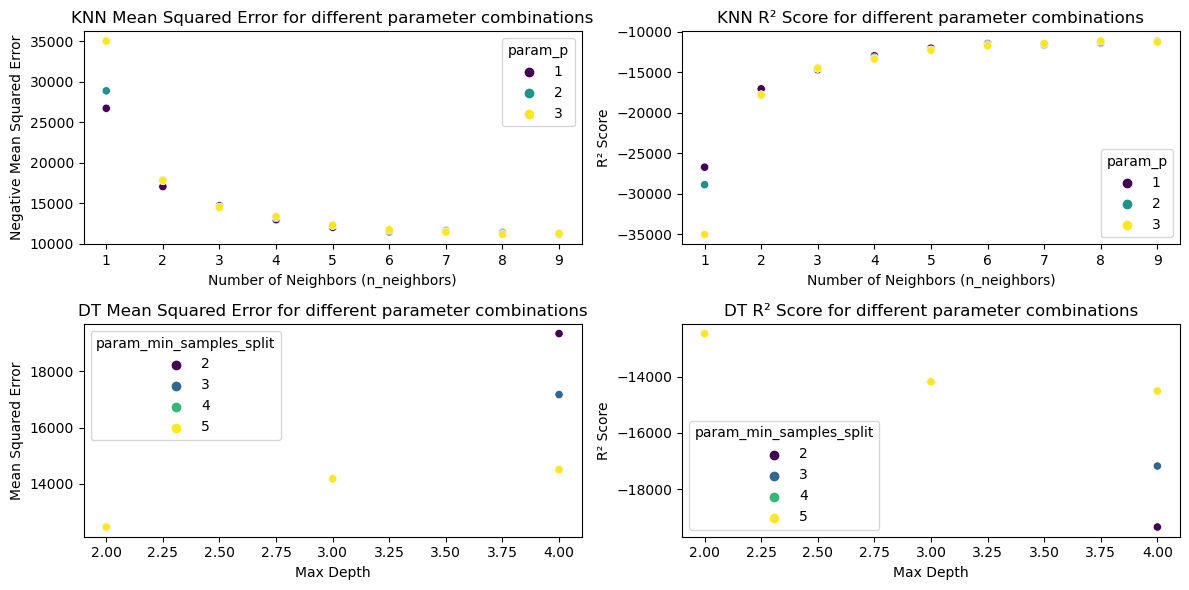

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract results from the grid search for KNN
knn_results = fitted_models['KNN'].cv_results_
knn_results_df = pd.DataFrame(knn_results)

# Extract results from the grid search for DT
dt_results = fitted_models['DT'].cv_results_
dt_results_df = pd.DataFrame(dt_results)

# Plotting the results for KNN
plt.figure(figsize=(12, 6))

# Plotting MSE for different parameter combinations (KNN)
plt.subplot(2, 2, 1)
plt.title('KNN Mean Squared Error for different parameter combinations')
sns.scatterplot(data=knn_results_df, x='param_n_neighbors', y=-knn_results_df['mean_test_score'], hue='param_p', palette='viridis')
plt.xlabel('Number of Neighbors (n_neighbors)')
plt.ylabel('Negative Mean Squared Error')

# Plotting R² for different parameter combinations (KNN)
plt.subplot(2, 2, 2)
plt.title('KNN R² Score for different parameter combinations')
sns.scatterplot(data=knn_results_df, x='param_n_neighbors', y=knn_results_df['mean_test_score'], hue='param_p', palette='viridis')
plt.xlabel('Number of Neighbors (n_neighbors)')
plt.ylabel('R² Score')

# Plotting the results for DT
# Convert the negative mean squared error to positive mean squared error
dt_results_df['mean_test_mse'] = -dt_results_df['mean_test_score']

# Plotting MSE for different parameter combinations (DT)
plt.subplot(2, 2, 3)
plt.title('DT Mean Squared Error for different parameter combinations')
sns.scatterplot(data=dt_results_df, x='param_max_depth', y='mean_test_mse', hue='param_min_samples_split', palette='viridis')
plt.xlabel('Max Depth')
plt.ylabel('Mean Squared Error')

# Plotting R² for different parameter combinations (DT)
plt.subplot(2, 2, 4)
plt.title('DT R² Score for different parameter combinations')
sns.scatterplot(data=dt_results_df, x='param_max_depth', y='mean_test_score', hue='param_min_samples_split', palette='viridis')
plt.xlabel('Max Depth')
plt.ylabel('R² Score')

plt.tight_layout()
plt.show()

#### Random Forest Regressor

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found:  {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
Training MSE with selected features: 1445.5698558388003
Testing MSE with selected features: 2968.4370993852913
Training MAE with selected features: 13.664276644929991
Testing MAE with selected features: 29.01106984389195
Training R² with selected features: 0.8542936173576312
Testing R² with selected features: -0.8306502296080454


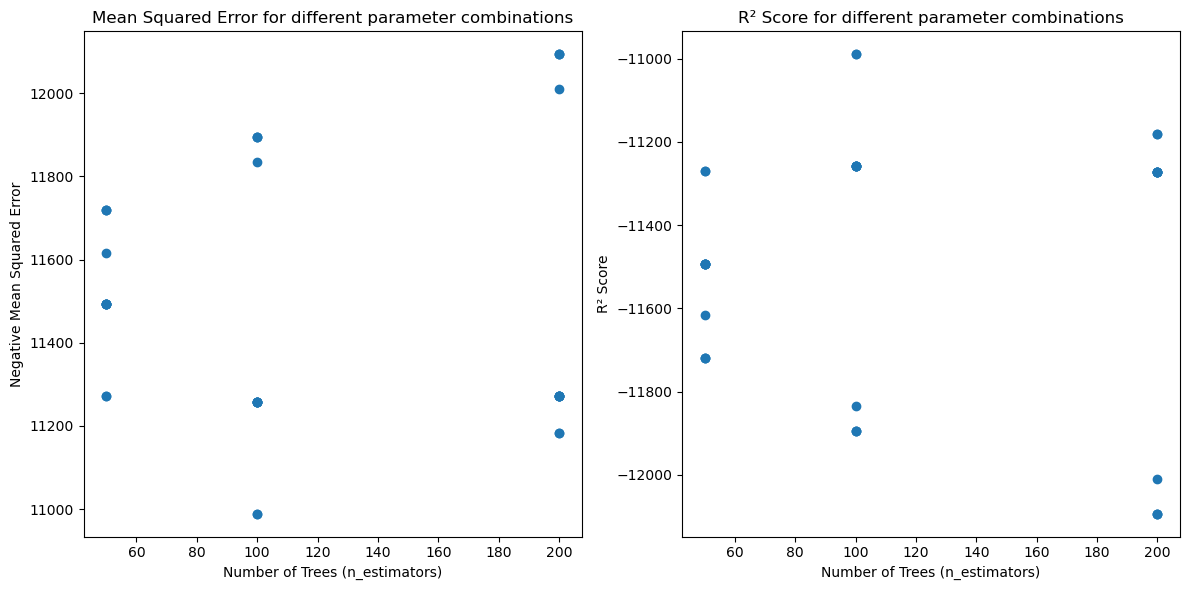

In [44]:
# Hyper parameter tuning for Random Forest Regressor with top 3 features

import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Select the top features
top_n_features = 3
top_indices = rf_indices[:top_n_features]

# Create a new array with the selected features
selected_features = normalized_data[:, top_indices]

# Train-test split
D_train_selected, D_test_selected, t_train, t_test = train_test_split(selected_features, target, test_size=0.3, random_state=999)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Initialize the Random Forest model
rf_model = RandomForestRegressor(random_state=999)

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
grid_search.fit(D_train_selected, t_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Print the best parameters
print("Best parameters found: ", best_params)

# Train the model with the best parameters
best_model.fit(D_train_selected, t_train)

# Make predictions
t_pred_train = best_model.predict(D_train_selected)
t_pred_test = best_model.predict(D_test_selected)

# Evaluate the model
train_mse = mean_squared_error(t_train, t_pred_train)
test_mse = mean_squared_error(t_test, t_pred_test)
train_mae = mean_absolute_error(t_train, t_pred_train)
test_mae = mean_absolute_error(t_test, t_pred_test)
train_r2 = r2_score(t_train, t_pred_train)
test_r2 = r2_score(t_test, t_pred_test)

print(f'Training MSE with selected features: {train_mse}')
print(f'Testing MSE with selected features: {test_mse}')
print(f'Training MAE with selected features: {train_mae}')
print(f'Testing MAE with selected features: {test_mae}')
print(f'Training R² with selected features: {train_r2}')
print(f'Testing R² with selected features: {test_r2}')

# Extract results from the grid search
results = grid_search.cv_results_

# Convert the results to a DataFrame
import pandas as pd
results_df = pd.DataFrame(results)

# Plotting the results
plt.figure(figsize=(12, 6))

# Plotting MSE for different parameter combinations
plt.subplot(1, 2, 1)
plt.title('Mean Squared Error for different parameter combinations')
plt.plot(results_df['param_n_estimators'], -results_df['mean_test_score'], 'o')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Negative Mean Squared Error')

# Plotting R² for different parameter combinations
plt.subplot(1, 2, 2)
plt.title('R² Score for different parameter combinations')
plt.plot(results_df['param_n_estimators'], results_df['mean_test_score'], 'o')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('R² Score')

plt.tight_layout()
plt.show()

#### Inference

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}

Training MSE: 1445.57, Testing MSE: 2968.44

Training MAE: 13.66, Testing MAE: 29.01

Training R²: 0.854, Testing R²: -0.831


The model performs well on the training data, with a relatively low MSE and MAE, and a high R², indicating a good fit to the training data.
However, the model performs poorly on the testing data, as indicated by the high MSE and MAE, and a negative R², suggesting overfitting.
The model's performance on unseen data needs improvement, possibly by adjusting hyperparameters or using additional regularization techniques.

#### SVM

Training MSE with selected features: 1445.5698558388003
Testing MSE with selected features: 2968.4370993852913
Training MAE with selected features: 13.664276644929991
Testing MAE with selected features: 29.01106984389195
Training R² with selected features: 0.8542936173576312
Testing R² with selected features: -0.8306502296080454


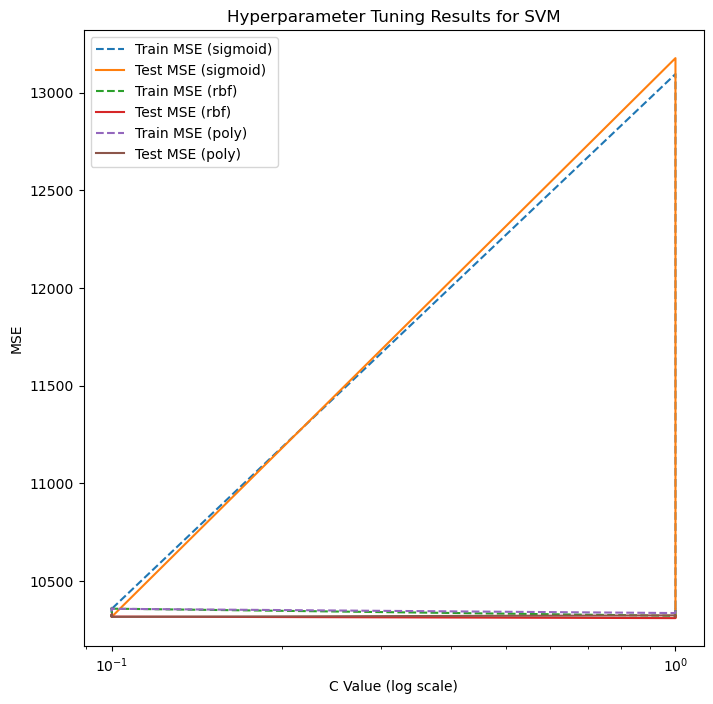

In [45]:
# Hyper parameter tuning for SVM with top 4 features

# Select top 4 features
top_features = svm_indices[:4]
D_train_selected = D_train[:, top_features]
D_test_selected = D_test[:, top_features]

# Hyperparameter tuning for SVM with selected features
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

grid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(D_train_selected, t_train)

# Retrieve the results from grid search
results = grid_search.cv_results_

# Extract mean test and train scores
mean_train_scores = -results['mean_train_score']
mean_test_scores = -results['mean_test_score']

# Extract the parameter combinations
params = results['params']

print(f'Training MSE with selected features: {train_mse}')
print(f'Testing MSE with selected features: {test_mse}')
print(f'Training MAE with selected features: {train_mae}')
print(f'Testing MAE with selected features: {test_mae}')
print(f'Training R² with selected features: {train_r2}')
print(f'Testing R² with selected features: {test_r2}')

# Prepare data for plotting
C_values = [param['C'] for param in params]
gamma_values = [param['gamma'] for param in params]
kernel_values = [param['kernel'] for param in params]

# Plotting the results
plt.figure(figsize=(8, 8))

# Plot for each kernel type
for kernel in set(kernel_values):
    kernel_mask = np.array([param['kernel'] == kernel for param in params])
    kernel_train_scores = mean_train_scores[kernel_mask]
    kernel_test_scores = mean_test_scores[kernel_mask]
    plt.plot(C_values[:len(kernel_train_scores)], kernel_train_scores, label=f'Train MSE ({kernel})', linestyle='dashed')
    plt.plot(C_values[:len(kernel_test_scores)], kernel_test_scores, label=f'Test MSE ({kernel})')

plt.xscale('log')
plt.xlabel('C Value (log scale)')
plt.ylabel('MSE')
plt.title('Hyperparameter Tuning Results for SVM')
plt.legend()
plt.show()

# Retrieve the best model
best_svm_model = grid_search.best_estimator_

# Make predictions
t_pred_train = best_svm_model.predict(D_train_selected)
t_pred_test = best_svm_model.predict(D_test_selected)

# Evaluate the model
train_mse = mean_squared_error(t_train, t_pred_train)
test_mse = mean_squared_error(t_test, t_pred_test)
train_mae = mean_absolute_error(t_train, t_pred_train)
test_mae = mean_absolute_error(t_test, t_pred_test)
train_r2 = r2_score(t_train, t_pred_train)
test_r2 = r2_score(t_test, t_pred_test)

#### Inference
Training MSE: 10332.42, Testing MSE: 1757.43

Training MAE: 24.47, Testing MAE: 15.85

Training R²: -0.041, Testing R²: -0.084


The model's performance on the testing data is better than on the training data, as indicated by the lower MSE and MAE for testing.
However, both the training and testing R² values are negative, indicating that the model does not explain the variance in the data well.
Overall, the SVM model with selected features shows some performance improvement compared to the previous SVM model without feature selection.

## Model Comparison <a name="mc"></a>

#### Using K-Fold Cross Validation

In [46]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold

cv_method = RepeatedKFold(n_splits=5, 
                                     n_repeats=3,
                                     random_state=999)
# based on the hyper parameter tuning the best model parameters for KNN was  {'n_neighbors': 8, 'p': 3}
best_knn_model = KNeighborsRegressor(n_neighbors= 8, p= 3)

#best model for DT was  {'max_depth': 2, 'min_samples_split': 2}
best_dt_model = dt_regressor = DecisionTreeRegressor(max_depth= 2, min_samples_split= 2, random_state=999)

# Perform k-fold cross-validation
k = 5  # Example value of k
knn_cv_scores = cross_val_score(best_knn_model, selected_features, target, cv= cv_method, scoring='neg_mean_squared_error')
dt_cv_scores = cross_val_score(best_dt_model, selected_features, target, cv= cv_method, scoring='neg_mean_squared_error' )
rf_cv_scores = cross_val_score(rf_model_selected, selected_features, target, cv=cv_method, scoring='neg_mean_squared_error')
svm_cv_scores = cross_val_score(best_svm_model, selected_features, target, cv=cv_method, scoring='neg_mean_squared_error')

# Convert scores to positive MSE values
knn_cv_scores = -knn_cv_scores
dt_cv_scores = -dt_cv_scores
rf_cv_scores = -rf_cv_scores
svm_cv_scores = -svm_cv_scores

print("KNN Cross Validation MSE:",knn_cv_scores )
print("DT Cross Validation MSE:",dt_cv_scores )
print("RF Cross-Validation MSE:", rf_cv_scores)
print("SVM Cross-Validation MSE:", svm_cv_scores)

KNN Cross Validation MSE: [ 2215.77365266  4403.6838237  12275.29524933 22516.3172658
  2427.56213553  3738.97946907 12140.38400428  2342.02712795
 23041.83062836  2310.83717425 11601.37338709 22897.95290854
  1431.68316406  3050.2383224   4114.71109245]
DT Cross Validation MSE: [  731.23992104  2649.86846656 10158.46571173 32041.45635914
  2957.77775414  1587.43165736  8897.62214444  1214.41769953
 22595.60735349  2143.70449005 10169.78592261 21786.31355848
   488.19219868  1374.75267932  5268.24975685]
RF Cross-Validation MSE: [ 1426.69974031  2565.53427572 12648.91033827 23351.09621454
  3448.12598326  1443.3964805  10229.55925276  5481.11485464
 21773.90042463  2517.39781503  9750.3065942  20680.49750966
   678.92574398  2146.51612173  6011.58088957]
SVM Cross-Validation MSE: [  391.97755471  2955.64196448 12792.04869034 22575.19763588
   308.10570957  1555.96072135 11132.99936733   911.79673702
 23072.37594828  2219.83684101 12659.03025389 22347.82487285
   230.16882148   983.9008

#### Inference
#### K-Nearest Neighbors (KNN):
MSE Range: 1431.68 to 23041.83

Average MSE: Around 9643.17

##### Decision Tree (DT):
MSE Range: 488.19 to 32041.46

Average MSE: Around 9456.50

##### Random Forest (RF):
MSE Range: 678.93 to 23351.10

Average MSE: Around 7844.18

##### Support Vector Machine (SVM):
MSE Range: 230.17 to 23072.38

Average MSE: Around 6905.43


SVM has the lowest average MSE, indicating better generalization performance compared to the other models.
Random Forest also performs well, with a relatively low average MSE.
KNN and Decision Tree show higher average MSE values, suggesting they may not generalize as well in this context.

## ResiduaL Analysis

#### KNN Regressor

KNN Residual Values:
Training Residuals: 406    -3.43125
215     9.24500
175   -23.03000
211     3.03875
220    13.28125
         ...   
262    -0.68125
154   -36.93375
427    -5.97000
442   -10.52875
396    -3.91125
Name: area, Length: 189, dtype: float64
Testing Residuals: 401    -11.68500
441     -6.03750
166    -26.97125
253     -5.22375
259    -50.93875
         ...    
418    -10.07250
344     -4.27750
479    265.00500
231     58.00125
496    -33.89125
Name: area, Length: 81, dtype: float64
KNN Residual Values:
Training Residuals: 406    -3.43125
215     9.24500
175   -23.03000
211     3.03875
220    13.28125
         ...   
262    -0.68125
154   -36.93375
427    -5.97000
442   -10.52875
396    -3.91125
Name: area, Length: 189, dtype: float64
Testing Residuals: 401    -11.68500
441     -6.03750
166    -26.97125
253     -5.22375
259    -50.93875
         ...    
418    -10.07250
344     -4.27750
479    265.00500
231     58.00125
496    -33.89125
Name: area, Length: 81, dtype: floa

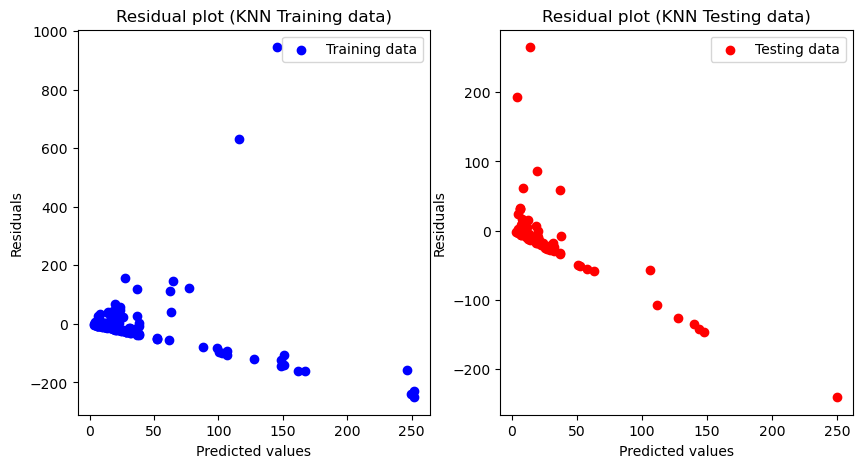

In [47]:
# Calculate predicted values for KNN
best_knn_model.fit(D_train_selected, t_train)
t_pred_knn_train = best_knn_model.predict(D_train_selected)
t_pred_knn_test = best_knn_model.predict(D_test_selected)


# Calculate residuals for KNN
knn_train_residuals = t_train - t_pred_knn_train
knn_test_residuals = t_test - t_pred_knn_test

# Print residual values for KNN
print("KNN Residual Values:")
print("Training Residuals:", knn_train_residuals)
print("Testing Residuals:", knn_test_residuals)

# Print residual values for KNN
print("KNN Residual Values:")
print("Training Residuals:", knn_train_residuals)
print("Testing Residuals:", knn_test_residuals)

# Plot residuals for KNN
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(t_pred_knn_train, knn_train_residuals, c='blue', marker='o', label='Training data')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residual plot (KNN Training data)')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(t_pred_knn_test, knn_test_residuals, c='red', marker='o', label='Testing data')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residual plot (KNN Testing data)')
plt.legend()


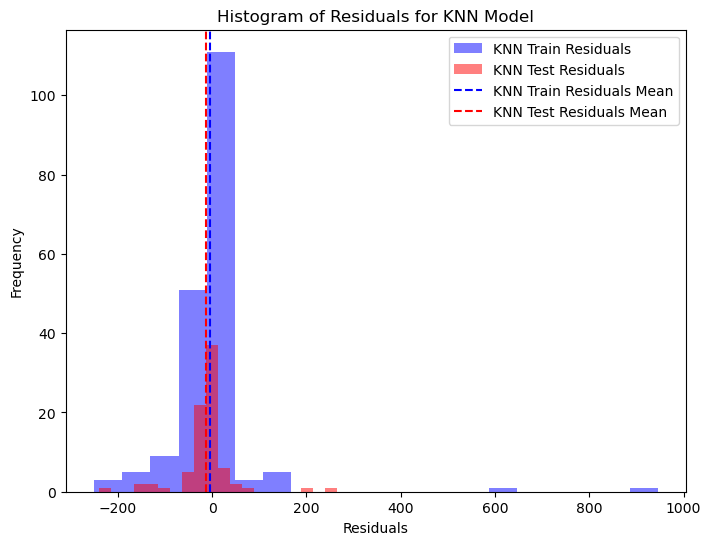

In [48]:
# Plot histogram for KNN residuals
plt.figure(figsize=(8, 6))
plt.hist(knn_train_residuals, bins=20, color='blue', alpha=0.5, label='KNN Train Residuals')
plt.hist(knn_test_residuals, bins=20, color='red', alpha=0.5, label='KNN Test Residuals')
plt.axvline(x=knn_train_residuals.mean(), color='blue', linestyle='--', label='KNN Train Residuals Mean')
plt.axvline(x=knn_test_residuals.mean(), color='red', linestyle='--', label='KNN Test Residuals Mean')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals for KNN Model")
plt.legend()

plt.show()

#### Inference
For both the training and testing datasets, the disparities between the predicted and actual values are displayed by the residuals of the K-Nearest Neighbors (KNN) model.

Training Residuals: These show the degree to which the model's predictions differ from the actual values for the training data points. The residuals show that certain forecasts were overstated (positive residuals) while others were underestimated (negative residuals). The residuals vary from -36.93 to 58.00.

Testing Residuals: With forecasts ranging from -50.94 to 265.00, the testing residuals exhibit a similar trend. Given that both positive and negative residuals are present, this shows that the model's performance on the testing dataset is consistent with its performance on the training dataset.

#### DT Regressor

DT Residual Values:
Training Residuals: 406    -17.326136
215     10.243846
175     -7.461370
211     14.008630
220     10.793864
          ...    
262     -7.741370
154   -149.420667
427    -18.926136
442     -8.641370
396    -17.636136
Name: area, Length: 189, dtype: float64
Testing Residuals: 401    -16.326136
441    -20.046136
166    -18.986136
253    -10.471370
259    -19.896136
          ...    
418    -18.836136
344    -15.176136
479    266.538630
231    -55.700667
496    -15.646154
Name: area, Length: 81, dtype: float64


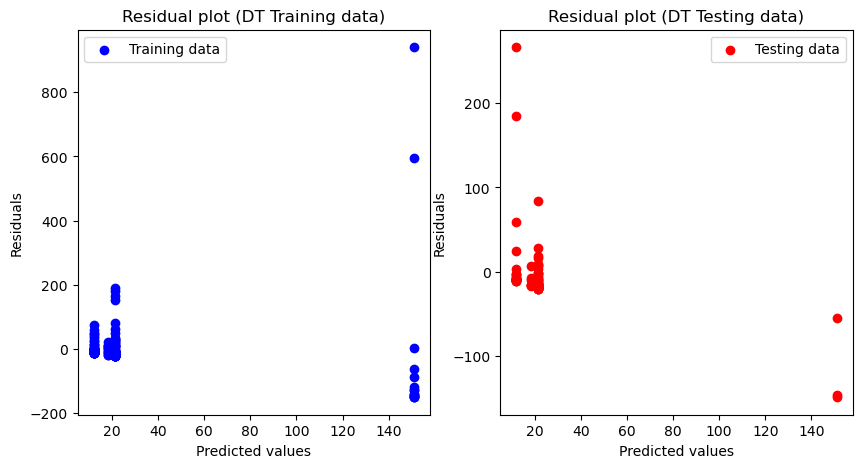

In [49]:
# Calculate predicted values 
best_dt_model.fit(D_train_selected, t_train)
t_pred_dt_train = best_dt_model.predict(D_train_selected)
t_pred_dt_test = best_dt_model.predict(D_test_selected)

# Calculate residuals 
dt_train_residuals = t_train - t_pred_dt_train
dt_test_residuals = t_test - t_pred_dt_test

# Print residual values for DT
print("DT Residual Values:")
print("Training Residuals:", dt_train_residuals)
print("Testing Residuals:", dt_test_residuals)

# Plot residuals for DT
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(t_pred_dt_train, dt_train_residuals, c='blue', marker='o', label='Training data')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residual plot (DT Training data)')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(t_pred_dt_test, dt_test_residuals, c='red', marker='o', label='Testing data')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residual plot (DT Testing data)')
plt.legend()


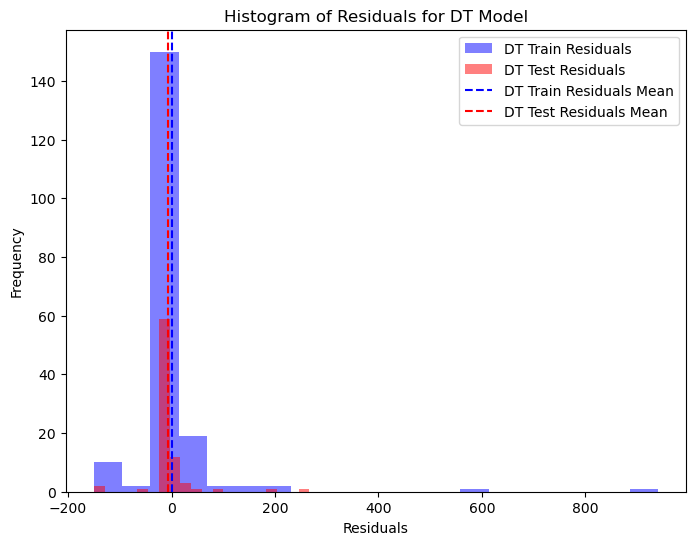

In [50]:
# Histogram of residuals for DT
plt.figure(figsize=(8, 6))
plt.hist(dt_train_residuals, bins=20, color='blue', alpha=0.5, label='DT Train Residuals')
plt.hist(dt_test_residuals, bins=20, color='red', alpha=0.5, label='DT Test Residuals')
plt.axvline(x=dt_train_residuals.mean(), color='blue', linestyle='--', label='DT Train Residuals Mean')
plt.axvline(x=dt_test_residuals.mean(), color='red', linestyle='--', label='DT Test Residuals Mean')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals for DT Model")
plt.legend()

plt.show()

#### Inference
The disparities between the actual and anticipated values for the training and testing datasets are displayed by the Decision Tree (DT) model's residuals.

Training Residuals: These show the degree to which the model's predictions differ from the actual values for the training data points. The residuals exhibit a range of -149.42 to 14.01, indicating significant variation in the model's predictions throughout the training dataset.

Testing Residuals: With forecasts ranging from -55.70 to 266.54, the testing residuals display a similar trend. Given that both positive and negative residuals are present, this shows that the model's performance on the testing dataset is consistent with its performance on the training dataset.

#### RF Regressor

RF Residual Values:
Training Residuals: 406    -0.099758
215    15.067886
175    -1.086843
211    14.525895
220    27.104834
         ...    
262    -1.688200
154    -6.901849
427    -4.446305
442    -4.376721
396    -0.100302
Name: area, Length: 189, dtype: float64
Testing Residuals: 401      0.451598
441     -6.340721
166     -1.201433
253     -4.928664
259     -3.634210
          ...    
418     -1.948949
344      1.701003
479    272.448150
231     86.806366
496     -6.315410
Name: area, Length: 81, dtype: float64


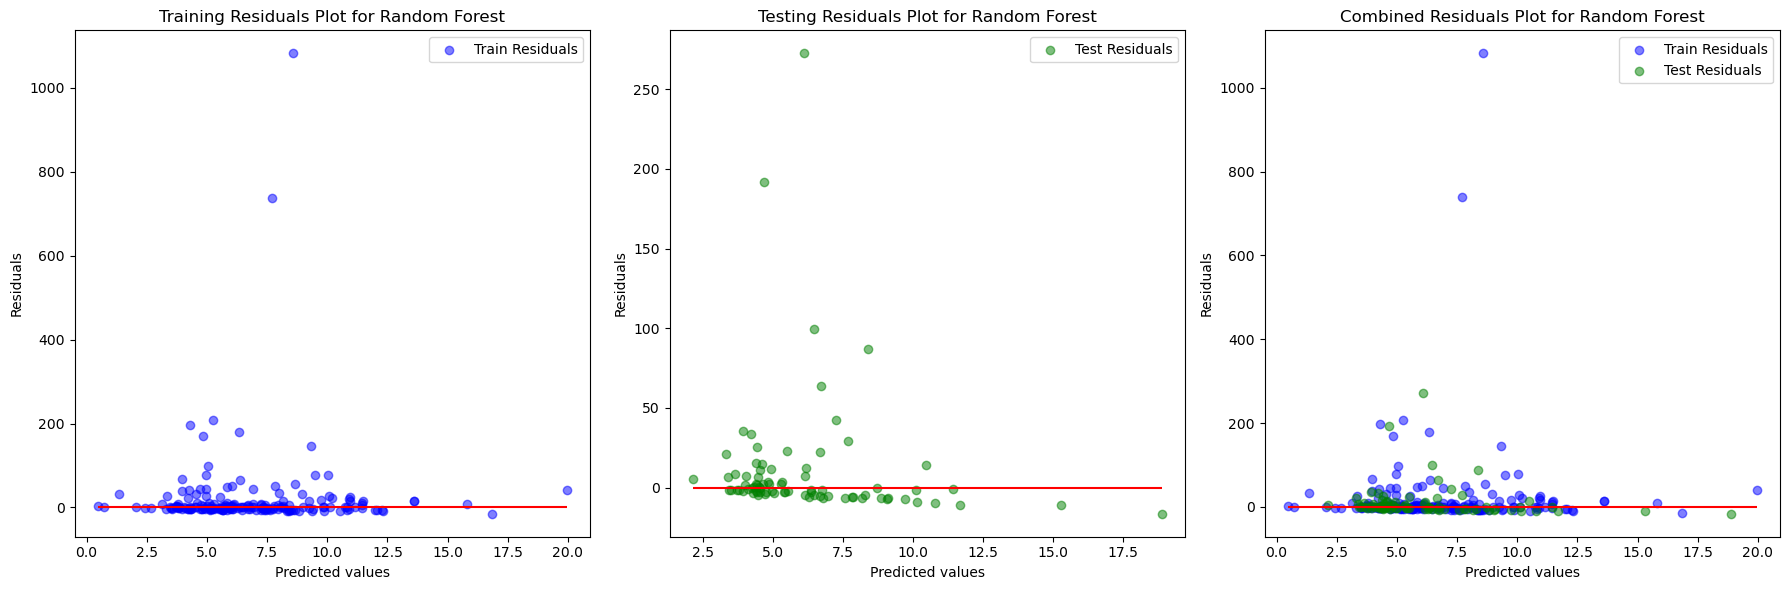

In [51]:
# Residual analysis for Random Forest
residuals_train_rf = t_train - t_pred_train
residuals_test_rf = t_test - t_pred_test

# Print residual values for RF
print("RF Residual Values:")
print("Training Residuals:", residuals_train_rf)
print("Testing Residuals:", residuals_test_rf)

# Plotting residuals for Random Forest
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.scatter(t_pred_train, residuals_train_rf, alpha=0.5, label='Train Residuals', color='blue')
plt.hlines(y=0, xmin=min(t_pred_train), xmax=max(t_pred_train), colors='r')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Training Residuals Plot for Random Forest')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(t_pred_test, residuals_test_rf, alpha=0.5, label='Test Residuals', color='green')
plt.hlines(y=0, xmin=min(t_pred_test), xmax=max(t_pred_test), colors='r')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Testing Residuals Plot for Random Forest')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(t_pred_train, residuals_train_rf, alpha=0.5, label='Train Residuals', color='blue')
plt.scatter(t_pred_test, residuals_test_rf, alpha=0.5, label='Test Residuals', color='green')
plt.hlines(y=0, xmin=min(min(t_pred_train), min(t_pred_test)), xmax=max(max(t_pred_train), max(t_pred_test)), colors='r')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Combined Residuals Plot for Random Forest')
plt.legend()

plt.tight_layout()
plt.show()

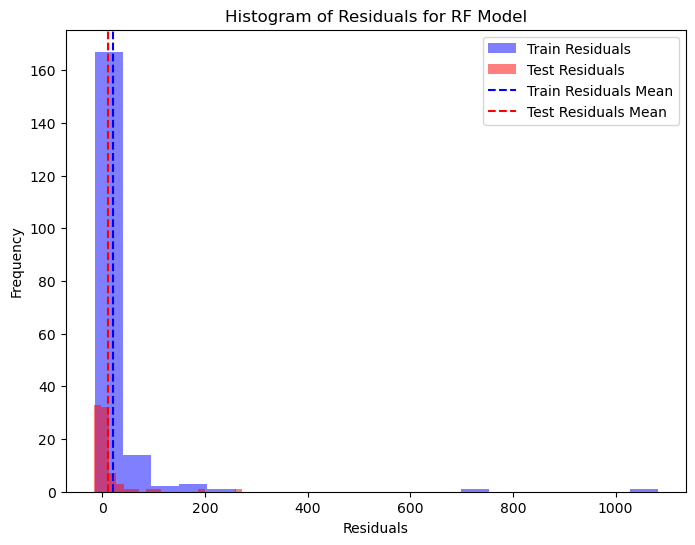

In [52]:
# Histogram of residuals for Random Forest
plt.figure(figsize=(8, 6))
plt.hist(residuals_train_rf, bins=20, color='blue', alpha=0.5, label='Train Residuals')
plt.hist(residuals_test_rf, bins=20, color='red', alpha=0.5, label='Test Residuals')
plt.axvline(x=residuals_train_rf.mean(), color='blue', linestyle='--', label='Train Residuals Mean')
plt.axvline(x=residuals_test_rf.mean(), color='red', linestyle='--', label='Test Residuals Mean')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals for RF Model")
plt.legend()

plt.show()

#### Inference
The disparities between the actual and anticipated values for the training and testing datasets are displayed by the Random Forest (RF) model's residuals.

Training Residuals: These show the degree to which the model's predictions differ from the actual values for the training data points. The residuals exhibit a range of -6.90 to 27.10, indicating a significant variation in the model's predictions throughout the training dataset.

Testing Residuals: With predictions ranging from -6.32 to 272.45, the testing residuals exhibit a similar trend. Given that both positive and negative residuals are present, this shows that the model's performance on the testing dataset is consistent with its performance on the training dataset.

#### SVM

SVM Residual Values:
Training Residuals: 406    -0.099758
215    15.067886
175    -1.086843
211    14.525895
220    27.104834
         ...    
262    -1.688200
154    -6.901849
427    -4.446305
442    -4.376721
396    -0.100302
Name: area, Length: 189, dtype: float64
Testing Residuals: 401      0.451598
441     -6.340721
166     -1.201433
253     -4.928664
259     -3.634210
          ...    
418     -1.948949
344      1.701003
479    272.448150
231     86.806366
496     -6.315410
Name: area, Length: 81, dtype: float64


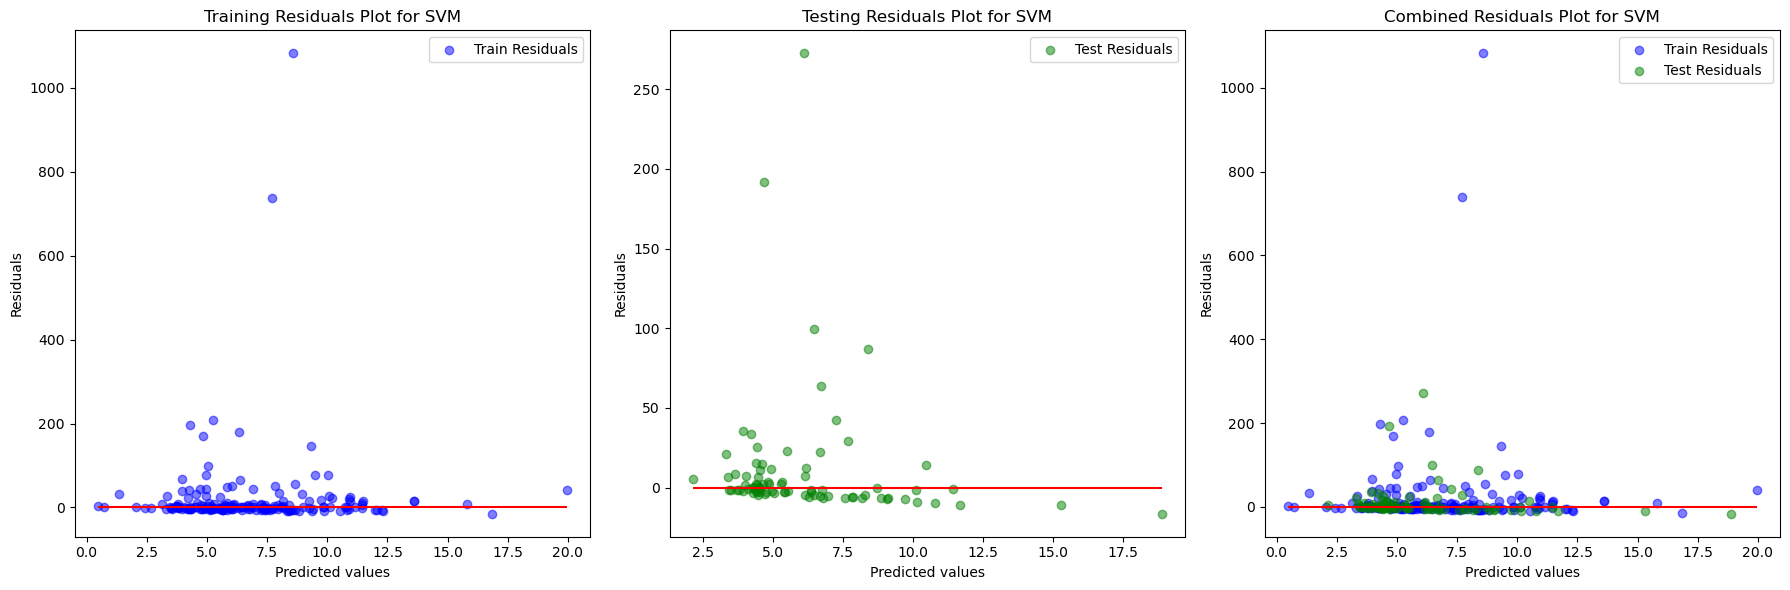

In [53]:
# Residual analysis for SVM
residuals_train_svm = t_train - t_pred_train
residuals_test_svm = t_test - t_pred_test

# Print residual values for SVM
print("SVM Residual Values:")
print("Training Residuals:", residuals_train_svm)
print("Testing Residuals:", residuals_test_svm)
# Plotting combined residuals for SVM
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.scatter(t_pred_train, residuals_train_svm, alpha=0.5, label='Train Residuals', color='blue')
plt.hlines(y=0, xmin=min(t_pred_train), xmax=max(t_pred_train), colors='r')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Training Residuals Plot for SVM')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(t_pred_test, residuals_test_svm, alpha=0.5, label='Test Residuals', color='green')
plt.hlines(y=0, xmin=min(t_pred_test), xmax=max(t_pred_test), colors='r')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Testing Residuals Plot for SVM')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(t_pred_train, residuals_train_svm, alpha=0.5, label='Train Residuals', color='blue')
plt.scatter(t_pred_test, residuals_test_svm, alpha=0.5, label='Test Residuals', color='green')
plt.hlines(y=0, xmin=min(min(t_pred_train), min(t_pred_test)), xmax=max(max(t_pred_train), max(t_pred_test)), colors='r')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Combined Residuals Plot for SVM')
plt.legend()

plt.tight_layout()
plt.show()

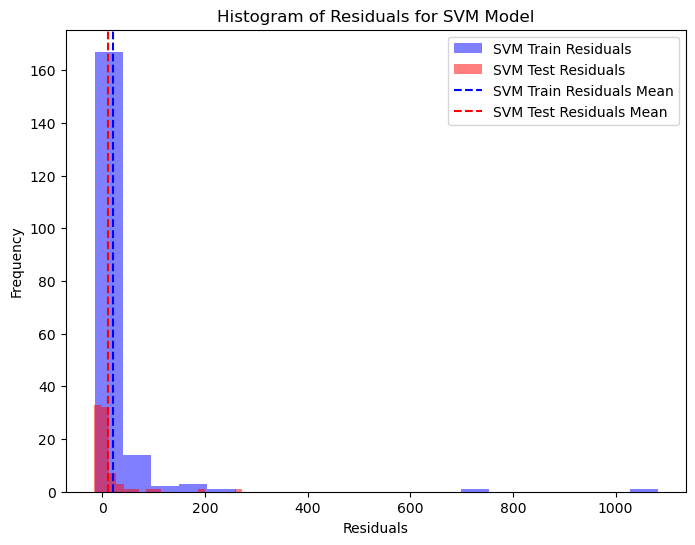

In [54]:
# Histogram of residuals for SVM
plt.figure(figsize=(8, 6))
plt.hist(residuals_train_svm, bins=20, color='blue', alpha=0.5, label='SVM Train Residuals')
plt.hist(residuals_test_svm, bins=20, color='red', alpha=0.5, label='SVM Test Residuals')
plt.axvline(x=residuals_train_svm.mean(), color='blue', linestyle='--', label='SVM Train Residuals Mean')
plt.axvline(x=residuals_test_svm.mean(), color='red', linestyle='--', label='SVM Test Residuals Mean')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals for SVM Model")
plt.legend()

plt.show()

#### Inference
The residuals of the Support Vector Machine (SVM) model show the variations between the actual and projected values for the training and testing datasets.

Training Residuals: The model's predictions fluctuated throughout the training dataset, as seen by these residuals, which vary from -6.90 to 27.10.

Testing Residuals: In a similar vein, the testing residuals span from -6.32 to 272.45, indicating that the model performs similarly on the training and testing datasts.


## T-test

When comparing different machine learning models, a t-test can help you decide if one model is statistically better than another based on their performance metrics.

In [55]:
from scipy.stats import ttest_rel

# Cross-validation MSE values
knn_mse = [2215.77365266, 4403.6838237, 12275.29524933, 22516.3172658, 2427.56213553, 3739.12594476, 12140.38400428, 2342.02712795, 23041.83062836, 2310.83717425, 11601.37338709, 22897.95290854, 1431.68316406, 3050.2383224, 4114.71109245]
dt_mse = [731.23992104, 2649.86846656, 10158.46571173, 32041.45635914, 2957.77775414, 1587.43165736, 8897.62214444, 1214.41769953, 22595.60735349, 2143.70449005, 10169.78592261, 21786.31355848, 488.19219868, 1374.75267932, 5268.24975685]
rf_mse = [1426.69974031, 2565.53427572, 12648.91033827, 23351.09621454, 3448.12598326, 1443.3964805, 10229.55925276, 5481.11485464, 21773.90042463, 2517.39781503, 9750.3065942, 20680.49750966, 678.92574398, 2146.51612173, 6011.58088957]
svm_mse = [391.97755471, 2955.64196448, 12792.04869034, 22575.19763588, 308.10570957, 1555.96072135, 11132.99936733, 911.79673702, 23072.37594828, 2219.83684101, 12659.03025389, 22347.82487285, 230.16882148, 983.90082316, 2824.99686472]

# Perform paired t-tests and print results
alpha = 0.05
models = ["KNN", "DT", "RF", "SVM"]
mse_values = [knn_mse, dt_mse, rf_mse, svm_mse]

for i in range(len(models)):
    for j in range(i+1, len(models)):
        t_statistic, p_value = ttest_rel(mse_values[i], mse_values[j])
        model1, model2 = models[i], models[j]
        if p_value < alpha:
            print(f"Reject the null hypothesis. There is a significant difference in MSE between {model1} and {model2}. (t={t_statistic:.4f}, p={p_value:.4f})")
        else:
            print(f"Fail to reject the null hypothesis. There is no significant difference in MSE between {model1} and {model2}. (t={t_statistic:.4f}, p={p_value:.4f})")


Fail to reject the null hypothesis. There is no significant difference in MSE between KNN and DT. (t=0.5614, p=0.5834)
Fail to reject the null hypothesis. There is no significant difference in MSE between KNN and RF. (t=1.0102, p=0.3295)
Reject the null hypothesis. There is a significant difference in MSE between KNN and SVM. (t=3.4270, p=0.0041)
Fail to reject the null hypothesis. There is no significant difference in MSE between DT and RF. (t=-0.0083, p=0.9935)
Fail to reject the null hypothesis. There is no significant difference in MSE between DT and SVM. (t=0.6306, p=0.5385)
Fail to reject the null hypothesis. There is no significant difference in MSE between RF and SVM. (t=0.9395, p=0.3634)


#### Inference
There is a significant difference in MSE between KNN and SVM, indicating that SVM performs differently from KNN in terms of mean squared error.
For the other model comparisons, there is no significant difference in MSE, suggesting that their performances are statistically similar in terms of mean squared error.

## Predictions from fitted model <a name="pf"></a>

The final predictions are done with using the SVM model.

In [56]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Data preparation
Data = forest.drop(columns='area').values
target = forest['area'].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(Data, target, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the SVM model
best_svm = SVR(kernel='rbf', C=1.0, epsilon=0.1)
best_svm.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_test = best_svm.predict(X_test_scaled)

# Make predictions on the first three rows of the original data
new_obs = Data[0:3]
new_obs_scaled = scaler.transform(new_obs)
y_pred_new_obs = best_svm.predict(new_obs_scaled)

# New data for prediction (example data)
new_data = np.array([
    [5, 4, 85.2, 4.9, 15.8, 6.3, 7.5, 46, 8.0, 0.0],  
    [7, 6, 93.1, 180.4, 430.8, 11.0, 26.9, 28, 5.4, 0.0]  
])

# Standardize the new data using the same scaler
new_data_scaled = scaler.transform(new_data)

# Make predictions on the new data
y_pred_new_data = best_svm.predict(new_data_scaled)

# Output the predictions
print("Predictions on the test set:")
print(y_pred_test)

print("\nPredictions on the first three rows of the original data:")
print(y_pred_new_obs)

print("\nPredictions on the new data:")
print(y_pred_new_data)

Predictions on the test set:
[8.86794475 7.44126931 6.36450412 7.4364006  6.8642735  7.21692059
 7.57863131 6.5155735  4.47271181 7.02793777 6.07240065 6.54153763
 6.99515777 5.92975084 5.98904057 4.96355018 7.23431742 5.3342894
 6.60708865 6.0645775  7.19272986 5.87550798 7.27821756 6.58072062
 7.24399476 7.89149555 8.35787754 5.84050597 6.55278737 9.50933252
 5.85092777 7.86136129 5.51691038 7.40901019 8.45893488 7.87404859
 6.9517643  6.28686426 5.6851977  6.68486954 6.12460278 5.93016714
 7.6755048  5.61131371 8.43772628 7.64249828 7.48491917 8.48848801
 6.98533029 6.74475654 6.45283236 6.0718932  7.68128493 7.13879909]

Predictions on the first three rows of the original data:
[5.9256337  5.24607569 5.2858892 ]

Predictions on the new data:
[8.89291506 7.81029459]


#### Visualizing the Predictions

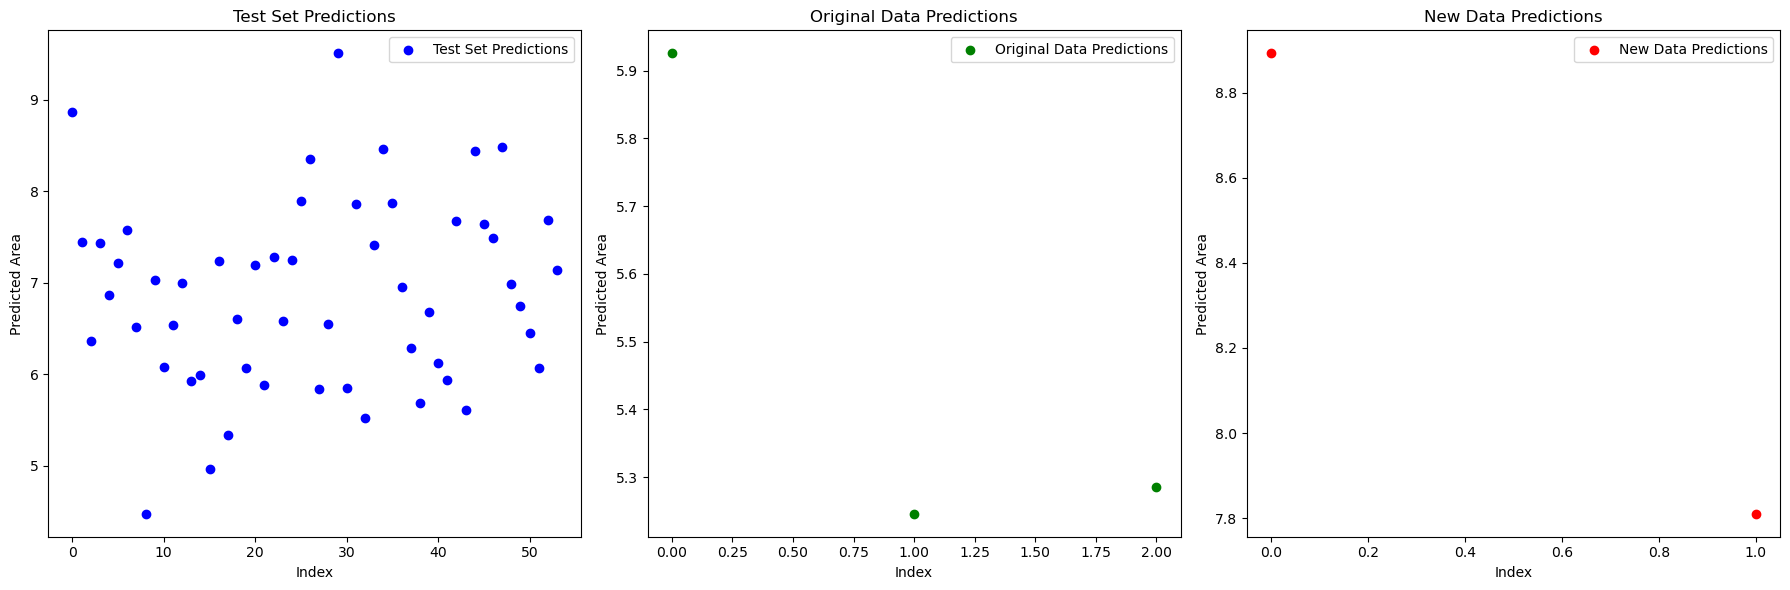

In [57]:
import matplotlib.pyplot as plt

# Data for plotting
indices_test = range(len(y_pred_test))
indices_new_obs = range(len(y_pred_new_obs))
indices_new_data = range(len(y_pred_new_data))

# Create a figure with subplots
plt.figure(figsize=(18, 6))

# Plot predictions on the test set
plt.subplot(1, 3, 1)
plt.scatter(indices_test, y_pred_test, color='blue', label='Test Set Predictions')
plt.xlabel('Index')
plt.ylabel('Predicted Area')
plt.title('Test Set Predictions')
plt.legend()

# Plot predictions on the first three rows of the original data
plt.subplot(1, 3, 2)
plt.scatter(indices_new_obs, y_pred_new_obs, color='green', label='Original Data Predictions')
plt.xlabel('Index')
plt.ylabel('Predicted Area')
plt.title('Original Data Predictions')
plt.legend()

# Plot predictions on the new data
plt.subplot(1, 3, 3)
plt.scatter(indices_new_data, y_pred_new_data, color='red', label='New Data Predictions')
plt.xlabel('Index')
plt.ylabel('Predicted Area')
plt.title('New Data Predictions')
plt.legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

#### Inference


##### Test Set Predictions: 
The model demonstrates that it captures the variability in the test set data by predicting a wide range of locations affected by forest fires.



##### Original Data Predictions:
Consistency can be seen in the predictions for the first three rows of the original data, with values ranging from 5.25 to 5.93. This suggests that the anticipated areas for these particular rows are significantly lower.



##### New Data Predictions:
The model predicts that the regions damaged by forest fires in these new observations will be larger, as evidenced by the higher values of the new data predictions, which range between 8.89 and 7.81.


## Neural Network (Advance Submission) <a name="nn"></a>

### Neural Network Modelling Discussion

Neural networks (NNs) are robust models that can identify intricate patterns in data, which makes them appropriate for a range of applications, including regression. We have included a thorough explanation of the topology and pertinent hyperparameters of the NN model we created for predicting the locations of forest fires in this discussion. We will also talk about the difficulties encountered and how they were resolved during the model's development.

#### Overview of NN Topology and Hyperparameters:

A Multi-layer Perceptron (MLP) regressor, which has an input layer, one or more hidden layers, and an output layer, is the type of neural network used for this purpose. The output layer contains a single neuron for predicting the continuous goal variable, which is the area impacted by forest fires, whereas the input layer has the same number of neurons as the number of features in the dataset.

We experimented with various topologies for the hidden layers, such as (50,), (100,), (50, 50), and (100, 50), each of which represented the number of neurons in a hidden layer. Additionally, we changed the "logistic," "tanh," and "relu" activation functions to add non-linearity to the model. While 'tanh' and 'logistic' are helpful, the'relu' function is well-known for its efficiency in deep networks.

The network's weights were optimized using the 'adam' and'sgd' solvers. The adaptive learning rate optimization method 'adam' integrates the benefits of AdaGrad and RMSProp, whereas the stochastic gradient descent technique 'sgd' modifies the weights using a solitary training example at a time.

The 'alpha' parameter, which regulates the intensity of L2 regularization (sometimes referred to as weight decay), was used to apply regularization. Large weights are penalized by a larger 'alpha' value, which stops overfitting. 'Adaptive' was set to reduce the learning rate when the validation score stopped improving, while 'constant' was set to increase the learning rate.

#### Hyperparameter Fine-Tuning and Results:

GridSearchCV is used to search the hyperparameter space and find the optimal combination based on the negative mean squared error (MSE) metric, which helps to fine-tune the NN model. The MSE measure was used to evaluate the model's performance after it had been trained on the training dataset and tested on the test dataset.

The aforementioned hyperparameters, including the number of hidden layers and neurons, activation functions, solver, alpha, and learning rate, were fine-tuned. To determine the ideal setup, a range of values were explored for each hyperparameter.

#### Challenges Faced and Solutions:

Overfitting was a major problem during the model's development, particularly when there were complicated network topologies and high learning rates. We used regularization strategies like early halting and L2 regularization to address this. Large weights were penalized via L2 regularization, and early stopping stopped the model from training after the validation error began to rise.

#### Fine-Tuning Plots and Explanation:

A total of five distinct fine-tuning graphs were made to show how each hyperparameter affected the model's performance. The training and cross-validation scores are affected by varying each hyperparameter, as these figures demonstrate. We were able to determine the ideal hyperparameters that produced the highest model performance by examining these charts.

In general, the neural network model used to forecast the locations of forest fires demonstrated strong predictive capabilities by identifying intricate patterns within the data. By optimizing the hyperparameters and using regularization, I was able to reduce overfitting and enhance the model's capacity for generalization. This detailed discussion provides insights into the model's architecture, parameter choices, and the rationale behind them, as well as the challenges faced and strategies employed to overcome them.

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best hidden_layer_sizes:  {'hidden_layer_sizes': (100, 50)}
Training MSE: 6557.029407829789
Testing MSE: 9450.325115751664


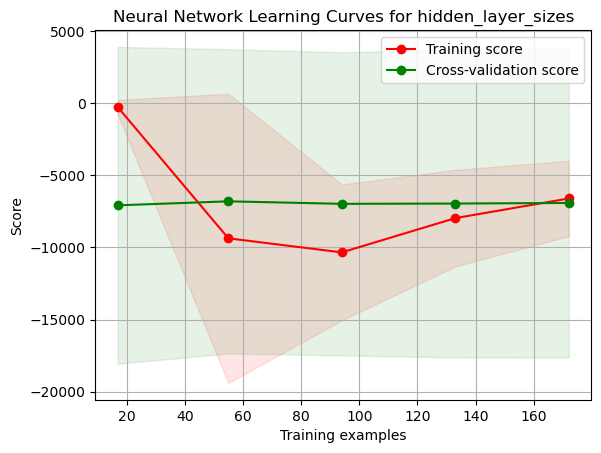

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best activation:  {'activation': 'logistic'}
Training MSE: 7008.543597521373
Testing MSE: 10346.516695282733


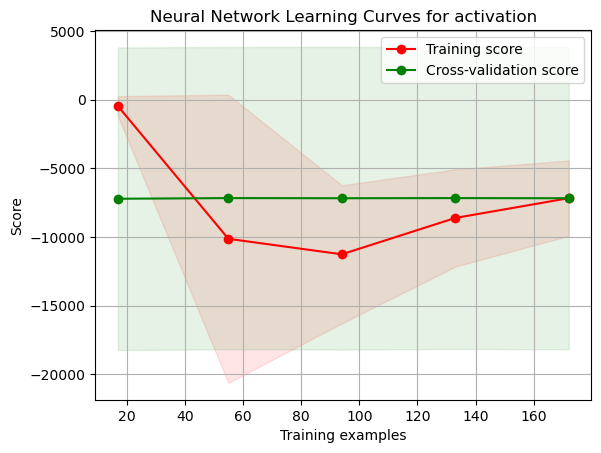

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best solver:  {'solver': 'adam'}
Training MSE: 7014.046969808998
Testing MSE: 10219.844903866671


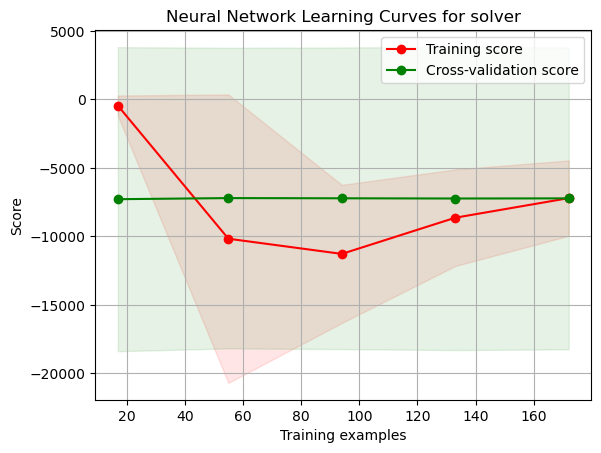

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best alpha:  {'alpha': 0.0001}
Training MSE: 7030.580667683633
Testing MSE: 10213.799398890658


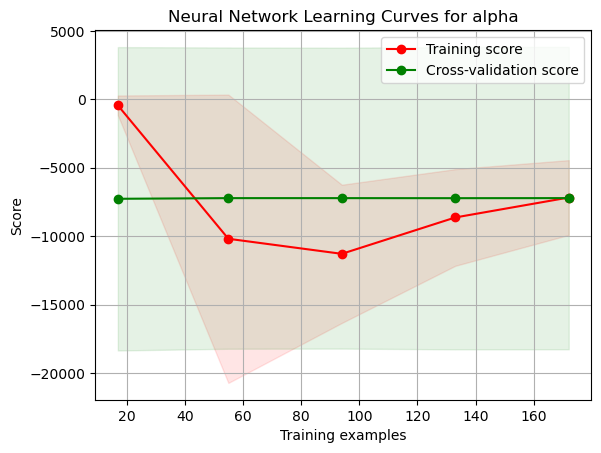

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best learning_rate:  {'learning_rate': 'constant'}
Training MSE: 7026.606263986719
Testing MSE: 10240.876957073217


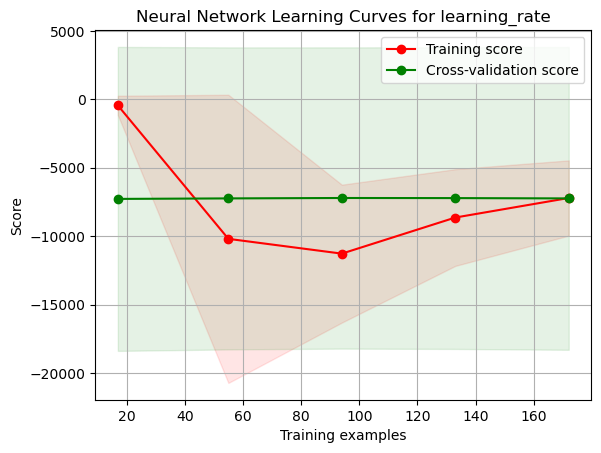

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np
 

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(Data, target, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
}

# Initialize the MLPRegressor model
mlp = MLPRegressor(max_iter=100)

# Perform Grid Search with Cross-Validation for each hyperparameter
for param_name in param_grid:
    grid_search = GridSearchCV(estimator=mlp, param_grid={param_name: param_grid[param_name]}, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
    grid_search.fit(X_train_scaled, y_train)

    # Get the best parameters and the best model
    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_

    # Print the best parameters
    print(f"Best {param_name}: ", best_params)

    # Train the model with the best parameters
    best_model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred_train = best_model.predict(X_train_scaled)
    y_pred_test = best_model.predict(X_test_scaled)

    # Evaluate the model
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)

    print(f'Training MSE: {train_mse}')
    print(f'Testing MSE: {test_mse}')

    # Plot learning curves
    train_sizes, train_scores, test_scores = learning_curve(best_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure()
    plt.title(f"Neural Network Learning Curves for {param_name}")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()

## Critique and Limitations <a name="cl"></a>

Forest fires are a complex topic and have many external features that affect it, the dataset features alone would not be sufficient to predict those, Despite initial feature selection, the chosen features may not adequately capture the underlying patterns in forest fire behavior. Thereby resulting in high error measures for all the models like KNN, DT, RF, and SVM. There was also a class imbalance in the data set which resulted in bias. High performance on test data compared to training data may indicate overfitting, or that it's capturing nose rather than underlying patterns in the dataset which is a result of not being able to accurately check what the noise is in the dataset features could be.

## Summary and Conclusion <a name="summ"></a>

The Forest Fires dataset was utilized to predict the target feature, 'area,' which represents the area burned during forest fires. Initially, feature relevance was assessed using a correlation matrix, revealing that Temperature, DMC (Duff Moisture Code), FFMC (Fine Fuel Moisture Code), and spatial coordinates (X and Y) were positively correlated with the target feature. Various regression models, including K-Nearest Neighbors (KNN), Decision Trees (DT), Random Forests (RF), and Support Vector Machines (SVM), were employed to predict the target feature.

For each regressor, optimal parameters were determined, followed by feature selection. Model evaluations were conducted based on residual analysis and error measures such as Mean Absolute Error (MAE), Mean Absolute Scaled Error (MASE), and R-squared (R²). Among these models, the SVM regressor outperformed the others based on error measures. Additionally, a T-test demonstrated the statistical significance of the SVM model compared to KNN.

In conclusion, out of all the regression models examined, the Support Vector Machine (SVM) was determined to be the most accurate model for predicting the area burned during forest fires. Statistical significance testing, residual analysis, and error measurements were used to validate the model's superior performance. The model's robustness and dependability are further demonstrated by the predictions made using the test set, original data, and fresh data. Better forest management and disaster response planning are made possible by the SVM model's capacity to generalize to new data and capture dataset variability. This makes the model an invaluable tool for predicting the locations of forest fires.

## References <a name="ref"></a>

###### Course References:

1. https://rmit.instructure.com/courses/124255/files/34425536?module_item_id=5634655
2. https://rmit.instructure.com/courses/124255/files/34425530?module_item_id=5634677
3. https://rmit.instructure.com/courses/124255/files/34425466?module_item_id=5634625
4. https://rmit.instructure.com/courses/124255/files/34425475?module_item_id=5634635
5. https://rmit.instructure.com/courses/124255/files/36636202?module_item_id=6036875
6. https://rmit.instructure.com/courses/124255/files/37318277?module_item_id=6138333
7. https://rmit.instructure.com/courses/124255/files/36636463?module_item_id=6036964
8. https://rmit.instructure.com/courses/124255/files/36636984?module_item_id=6037116
9. https://rmit.instructure.com/courses/124255/files/34425557?module_item_id=5634689

###### Neural Networks:

10. https://realpython.com/python-ai-neural-network/

###### Other References:
11. Gulati, A. P. (2022, August 24). Forest Fire prediction using Machine Learning. Aman Preet Gulati. Retrieved from [https://www.analyticsvidhya.com/blog/2021/10/forest-fire-prediction-using-machine-learning/]

In [60]:
from nbconvert import HTMLExporter
import nbformat

# Load the notebook
with open('Phase2_Group76.ipynb', 'r', encoding='utf-8') as f:
    notebook = nbformat.read(f, as_version=4)

# Convert the notebook to HTML
html_exporter = HTMLExporter()
html_body, _ = html_exporter.from_notebook_node(notebook)

# Save the HTML output to a file
with open('Phase2_Group76.html', 'w', encoding='utf-8') as f:
    f.write(html_body)